# Benchmark of Explainability Techniques for Neural Networks in Banking Fraud Detection
### Post-hoc XAI methods vs. TabNet's native attention — fidelity, robustness, stability, and calibration-aware evaluation

**Author:** Andrea Claudia Villanca Rosales
**Master's Thesis (TFM) — Big Data, Inteligencia Artificial e Ingeniería de Datos, Universidad de Málaga**

This notebook picks up where `TFM_EDA_Training_Evaluation.ipynb` left off: it loads the trained
TabNet model and preprocessed data exported in that notebook's Section 6, and runs the final XAI
benchmark for the thesis. It covers:

1. **Post-hoc XAI methods:** SHAP (`KernelExplainer` + `GradientExplainer`), LIME, and Integrated
   Gradients (Captum) — both global (feature importance) and local (per-instance / "solicitud de
   cuenta") explanations, using real-training-row backgrounds and baselines throughout rather than
   synthetic centroids or all-zero vectors, which are invalid for one-hot encoded categorical data.
2. **Comparison with TabNet's native explainability** (its per-step attention masks), reported
   separately from the post-hoc methods since its own perturbation-based fidelity does not support
   treating it as a faithful local explanation.
3. **Visualizations:** beeswarm plots, waterfall charts, and per-instance force plots, built around
   one consistent example instance so all methods can be compared side by side.
4. **Calibration and output-scale diagnostics:** Platt/isotonic calibration checks and a logit-target
   fidelity cross-check, so explanation quality is not confounded with the model's known score
   miscalibration under SMOTE-based training.
5. **Quantitative evaluation of explanation quality:** fidelity (one-hot-aware, perturbing whole
   original variables), robustness (scale-normalized relative sensitivity), and stability
   (nearest-neighbor cosine similarity) — implemented as transparent, self-contained manual metrics
   after Quantus proved incompatible with flat tabular arrays in practice, with bootstrap confidence
   intervals for every final number.
6. **Independent validation and proxy-risk discussion:** grouped permutation importance confirms the
   dominant categorical variables independently of any XAI method, and the results are discussed as a
   banking proxy-risk/fairness concern, not only as an interpretability finding.
7. **Cross-method comparison:** ranking correlations, population-vs-balanced-subset checks, summary
   tables and charts, closing with method-specific recommendations for this fraud-detection setting.


## 0. Environment Setup
In addition to the libraries used for training, this notebook needs the XAI-specific
packages: `shap`, `lime`, `captum` (for Integrated Gradients), and `quantus` (for
quantitative evaluation — with a manual fallback implemented later in case the installed
Quantus version's API differs).

**Steps performed below:** install (commented out) the extra XAI packages, import them, and
print installed versions.

In [1]:
# Install packages in the environment
# !pip install shap lime captum quantus --quiet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer
from captum.attr import IntegratedGradients

# Quantus is optional -- we try to import it, but the notebook does not hard-depend on it
try:
    import quantus
    QUANTUS_AVAILABLE = True
except ImportError:
    QUANTUS_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("SHAP version:", shap.__version__)
print("Quantus available:", QUANTUS_AVAILABLE)
print("PyTorch version:", torch.__version__)

SHAP version: 0.52.0
Quantus available: True
PyTorch version: 2.13.0+cpu


### 0.1 Speed / thoroughness trade-off

Some of the methods below (`SHAP.KernelExplainer`, `LIME`) are model-agnostic and
therefore call `predict_proba` hundreds of times **per instance explained**, so they can be
slow on CPU. `QUICK_MODE` controls how many instances/samples are used for the more
expensive steps, so we can validate the whole notebook runs end-to-end quickly, then
switch to a more thorough run for the final results.

In [3]:
QUICK_MODE = False  # set to False for the final, more thorough thesis run

if QUICK_MODE:
    N_KERNEL_LIME_INSTANCES = 30   # instances explained with KernelExplainer / LIME (expensive)
    KERNEL_NSAMPLES = 100          # SHAP KernelExplainer perturbation samples per instance
    LIME_NUM_SAMPLES = 500         # LIME perturbation samples per instance
    FIDELITY_N_INSTANCES = 20
    FIDELITY_NR_RUNS = 15
    ROBUSTNESS_N_INSTANCES_FAST = 30   # for gradient-based / native methods (cheap to recompute)
    ROBUSTNESS_N_INSTANCES_SLOW = 10   # for KernelExplainer / LIME (expensive to recompute)
    ROBUSTNESS_N_REPEATS = 5
else:
    N_KERNEL_LIME_INSTANCES = 100
    KERNEL_NSAMPLES = 300
    LIME_NUM_SAMPLES = 2000
    FIDELITY_N_INSTANCES = 50
    FIDELITY_NR_RUNS = 30
    ROBUSTNESS_N_INSTANCES_FAST = 100
    ROBUSTNESS_N_INSTANCES_SLOW = 25
    ROBUSTNESS_N_REPEATS = 10

print("QUICK_MODE:", QUICK_MODE)


QUICK_MODE: False


## 1. Load Model & Data Exported from the Training Notebook

**Goal:** load everything needed for XAI, exactly as it was produced by
`TFM_EDA_Training_Evaluation.ipynb` Section 6 — no retraining, no re-preprocessing.

**Expected result:** the trained `clf` (TabNetClassifier), the fitted `preprocessor`, the
processed data splits, the ordered `feature_names`, a K-Means-summarized SHAP background,
a fixed 200-instance explanation subset (`X_explain_proc` / `y_explain`), TabNet's native
explanation for that exact subset, its global feature importance, and the run's metadata.


In [4]:
EXPORT_DIR = Path("baf_xai_export")

if not EXPORT_DIR.exists():
    zip_path = Path("baf_xai_export.zip")
    assert zip_path.exists(), (
        "Neither baf_xai_export/ nor baf_xai_export.zip found in the working directory. "
        "Copy them here from the training notebook first."
    )
    import shutil
    shutil.unpack_archive(str(zip_path), ".")
    print("Unzipped", zip_path)

print("Export directory contents:")
for f in sorted(EXPORT_DIR.iterdir()):
    print(" -", f.name)


Export directory contents:
 - explain_subset.npz
 - feature_names.json
 - metadata.json
 - preprocessor.joblib
 - processed_arrays.npz
 - shap_background.npy
 - shap_background_real_row_indices.npy
 - shap_background_real_rows.npy
 - tabnet_global_importance.csv
 - tabnet_model.zip
 - tabnet_native_explanation.npz
 - test_raw.csv


**1.a Load the trained model and the fitted preprocessing pipeline.**

**What to check:** the printed network architecture should list TabNet's feature
transformer / attention blocks with no error. A version-mismatch error here usually means
the installed `pytorch-tabnet` version differs from the one used to train and export the
model.

In [5]:
# Trained TabNet model
clf = TabNetClassifier()
clf.load_model(str(EXPORT_DIR / "tabnet_model.zip"))
clf.network.eval()  # inference mode (freezes Ghost Batch Norm running stats)

# Fitted preprocessing pipeline (not strictly needed for XAI on already-processed data,
# but useful if you want to explain a brand-new, raw application later)
preprocessor = joblib.load(EXPORT_DIR / "preprocessor.joblib")

print("Model loaded. Network architecture:")
print(clf.network)


Model loaded. Network architecture:
TabNet(
  (embedder): EmbeddingGenerator()
  (tabnet): TabNetNoEmbeddings(
    (initial_bn): BatchNorm1d(48, eps=1e-05, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (encoder): TabNetEncoder(
      (initial_bn): BatchNorm1d(48, eps=1e-05, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (initial_splitter): FeatTransformer(
        (shared): GLU_Block(
          (shared_layers): ModuleList(
            (0): Linear(in_features=48, out_features=64, bias=False)
            (1): Linear(in_features=32, out_features=64, bias=False)
          )
          (glu_layers): ModuleList(
            (0): GLU_Layer(
              (fc): Linear(in_features=48, out_features=64, bias=False)
              (bn): GBN(
                (bn): BatchNorm1d(64, eps=1e-05, momentum=0.02, affine=True, bias=True, track_running_stats=True)
              )
            )
            (1): GLU_Layer(
              (fc): Linear(in_features=32, 

**1.b Load the processed train/validation/test splits.**

**What to check:** `X_train_proc` / `X_test_proc` shapes should match what the training
notebook reported at export time. If the row counts look unexpectedly small or large, the
wrong export folder is likely being loaded (check `EXPORT_DIR` above).


In [6]:
# Processed data splits
arrays = np.load(EXPORT_DIR / "processed_arrays.npz")
X_train_proc, y_train = arrays["X_train_proc"], arrays["y_train"]
X_val_proc, y_val = arrays["X_val_proc"], arrays["y_val"]
X_test_proc, y_test = arrays["X_test_proc"], arrays["y_test"]
X_train_res, y_train_res = arrays["X_train_res"], arrays["y_train_res"]

print("X_train_proc:", X_train_proc.shape, "| X_test_proc:", X_test_proc.shape)


X_train_proc: (794989, 48) | X_test_proc: (96843, 48)


**1.c Load the feature-name mapping.**

**What to check:** `N_FEATURES` should match the number of columns in `X_train_proc` from
the previous cell. `categorical_features` should list the *original* (pre-one-hot) column
names (e.g. `housing_status`), not the expanded one-hot dummy names -- this list is reused
later in Section 7.2 to aggregate dummies back to their parent variable.


In [7]:
# Feature names (post-preprocessing, model-input order)
with open(EXPORT_DIR / "feature_names.json") as f:
    names = json.load(f)
feature_names = names["feature_names"]
numerical_features = names["numerical_features"]      # pre-preprocessing numeric columns
categorical_features = names["categorical_features"]  # pre-preprocessing categorical columns (pre-one-hot)
N_FEATURES = len(feature_names)

print(f"{N_FEATURES} model-input features.")
print("First 10:", feature_names[:10])
print("Original categorical variables (pre-one-hot):", categorical_features)


48 model-input features.
First 10: ['income', 'name_email_similarity', 'current_address_months_count', 'customer_age', 'days_since_request', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w']
Original categorical variables (pre-one-hot): ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


**1.d Load the SHAP background and the fixed explanation subset.**

**What to check:** the printed fraud/legit split should be roughly balanced (~100/100 by
construction) -- this fixed, balanced subset is what makes every method in Sections 3-8
directly comparable to each other.


In [8]:
# SHAP background summary (K-Means, 50 points) and the fixed 200-instance explanation subset
shap_background = np.load(EXPORT_DIR / "shap_background.npy")

explain_subset = np.load(EXPORT_DIR / "explain_subset.npz")
explain_indices = explain_subset["indices"]
X_explain = explain_subset["X_explain_proc"]
y_explain = explain_subset["y_explain"]

print("SHAP background shape:", shap_background.shape)
print("Explanation subset shape:", X_explain.shape,
      f"-- {int(y_explain.sum())} fraud / {int((1 - y_explain).sum())} legit")


SHAP background shape: (50, 48)
Explanation subset shape: (200, 48) -- 100 fraud / 100 legit


### 1.1 Fixing a bug in the exported SHAP background

**Diagnostic finding from the last run:** `KernelExplainer`'s `expected_value` (the
background's average predicted P(fraud)) came back as **1.0** -- i.e. the model predicts
essentially certain fraud for every point in the SHAP background. That's not a plausible
"neutral reference point" (the real fraud rate is ~1-2%), and it's very likely the root
cause of several downstream oddities: SHAP `KernelExplainer`'s persistently negative
fidelity even after the one-hot-aware fix, and (to a lesser extent) `GradientExplainer`'s
results, since both are computed *relative to this background*.

**Root cause:** the training notebook's export step (Section 6.6) built the background by
running K-Means on `X_train_res` -- the **SMOTE-resampled** training set (50/50,
partly-synthetic). Averaging synthetic, interpolated minority-class points into K-Means
centroids can produce feature combinations that don't correspond to any real application
and sit in a region of input space the model was never really trained to handle sensibly,
which is consistent with it saturating to P(fraud)=1.0.

**Fix:** rebuild the background via K-Means on `X_train_proc` -- the **original, real,
un-resampled** training distribution -- so the background represents plausible
applications and its average prediction is close to the real base fraud rate.

**What to check:** the diagnostic print should first show the *broken* background's mean
P(fraud) close to 1.0, then -- once the fix runs -- a corrected mean P(fraud) much closer to
the true fraud prevalence (~1-2%). If it prints "no fix needed" instead, the exported
background was already valid and nothing downstream changes.


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# IMPORTANT FIX:
# The training notebook exported shap_background.npy from KMeans centroids on X_train_res
# (SMOTE-resampled data). Rebuilding KMeans on X_train_proc is not enough, because centroids
# in a mixed standardized-numeric + one-hot feature space are still synthetic off-manifold
# records (fractional one-hot blocks). For SHAP/LIME/IG-style baselines we need VALID rows.
# Therefore, use KMeans only to find representative regions, then select the nearest REAL
# training row to each centroid (a medoid-like background).

N_BACKGROUND = 50
BACKGROUND_CANDIDATE_SIZE = 20000  # speeds up KMeans while keeping a representative pool
rng_background = np.random.RandomState(RANDOM_STATE)


def predict_mean_fraud(X, batch_size=50000):
    """Mean model P(fraud), batched to avoid memory spikes."""
    probs = []
    for start in range(0, X.shape[0], batch_size):
        probs.append(clf.predict_proba(X[start:start + batch_size].astype(np.float32))[:, 1])
    return float(np.concatenate(probs).mean())


def select_real_kmeans_medoids(X_real, n_background=50, candidate_size=20000,
                               random_state=RANDOM_STATE):
    """Return real training rows closest to KMeans centroids.

    The returned rows are on-manifold: one-hot categorical blocks remain valid because rows
    come directly from X_train_proc, unlike KMeans centroids.
    """
    rng = np.random.RandomState(random_state)
    n_candidates = min(candidate_size, X_real.shape[0])
    candidate_idx = rng.choice(X_real.shape[0], size=n_candidates, replace=False)
    candidates = X_real[candidate_idx].astype(np.float32)

    n_clusters = min(n_background, n_candidates)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(candidates)

    closest_local_idx, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, candidates)
    # np.unique can reduce the count if two centroids select the same medoid; top up with real rows.
    selected_global_idx = list(dict.fromkeys(candidate_idx[closest_local_idx].tolist()))
    if len(selected_global_idx) < n_background:
        remaining = [i for i in candidate_idx.tolist() if i not in set(selected_global_idx)]
        selected_global_idx.extend(remaining[:n_background - len(selected_global_idx)])
    selected_global_idx = np.array(selected_global_idx[:n_background])
    return X_real[selected_global_idx].astype(np.float32), selected_global_idx


# Diagnostics for the exported background and for the model's own average prediction on real data.
exported_bg_pred = predict_mean_fraud(shap_background.astype(np.float32))
train_base_rate = float(np.mean(y_train))
train_diag_idx = rng_background.choice(X_train_proc.shape[0], size=min(20000, X_train_proc.shape[0]), replace=False)
train_pred_mean = predict_mean_fraud(X_train_proc[train_diag_idx].astype(np.float32))

print(f"Exported background -- mean P(fraud): {exported_bg_pred:.4f}")
print(f"Real training fraud base rate:          {train_base_rate:.4f}")
print(f"Model mean P(fraud) on real train sample: {train_pred_mean:.4f}")

# Build a real-row medoid background.
shap_background, background_indices = select_real_kmeans_medoids(
    X_train_proc,
    n_background=N_BACKGROUND,
    candidate_size=BACKGROUND_CANDIDATE_SIZE,
    random_state=RANDOM_STATE,
)
medoid_bg_pred = predict_mean_fraud(shap_background)
print(f"Real-medoid background -- mean P(fraud): {medoid_bg_pred:.4f}")

# If medoids still look pathological, fall back to simple random REAL training rows. This keeps
# the notebook robust and makes the failure visible rather than silently using a bad baseline.
# We compare against the model's mean prediction on real training data, not only the empirical
# label base rate, because probability calibration may be imperfect.
upper_reasonable = max(0.10, 5 * train_pred_mean, 5 * train_base_rate)
if medoid_bg_pred > upper_reasonable or medoid_bg_pred > 0.95:
    print("\nWARNING: medoid background still has implausible mean P(fraud).")
    print("Falling back to random real training rows for SHAP/IG baselines.")
    background_indices = rng_background.choice(X_train_proc.shape[0], size=N_BACKGROUND, replace=False)
    shap_background = X_train_proc[background_indices].astype(np.float32)
    random_bg_pred = predict_mean_fraud(shap_background)
    print(f"Random real-row background -- mean P(fraud): {random_bg_pred:.4f}")

np.save(EXPORT_DIR / "shap_background_real_rows.npy", shap_background)
np.save(EXPORT_DIR / "shap_background_real_row_indices.npy", background_indices)
print("Saved real-row SHAP background:", EXPORT_DIR / "shap_background_real_rows.npy")
print("SHAP background shape:", shap_background.shape)

# Baseline pool for IG and perturbation metrics. These are valid, real preprocessed rows.
xai_baseline_pool = shap_background.astype(np.float32)
# Empirical mean kept only for diagnostics/optional use; the main metrics below use real-row references.
xai_baseline_vector = X_train_proc.mean(axis=0).astype(np.float32)


Exported background -- mean P(fraud): 1.0000
Real training fraud base rate:          0.0103
Model mean P(fraud) on real train sample: 0.1697
Real-medoid background -- mean P(fraud): 0.2481
Saved real-row SHAP background: baf_xai_export\shap_background_real_rows.npy
SHAP background shape: (50, 48)


In [10]:
# Population-representative explanation subset.
# The original X_explain is intentionally balanced (100 fraud / 100 legit), which is useful
# for method diagnostics, but it is NOT representative of deployment prevalence.
# Use this population subset for real-distribution global sanity checks.

N_POP_EXPLAIN = 1000 if not QUICK_MODE else 300
rng_pop = np.random.RandomState(RANDOM_STATE)
pop_indices = rng_pop.choice(X_test_proc.shape[0], size=min(N_POP_EXPLAIN, X_test_proc.shape[0]), replace=False)
X_explain_pop = X_test_proc[pop_indices].astype(np.float32)
y_explain_pop = y_test[pop_indices]

print("Balanced diagnostic subset:", X_explain.shape, f"fraud rate={y_explain.mean():.4f}")
print("Population explanation subset:", X_explain_pop.shape, f"fraud rate={y_explain_pop.mean():.4f}")
print("Real test fraud rate:", float(np.mean(y_test)))

# Interpretation rule:
# - Balanced subset: compare behavior on fraud vs legit cases and inspect local examples.
# - Population subset: discuss deployment/global feature importance and real-prevalence behavior.


Balanced diagnostic subset: (200, 48) fraud rate=0.5000
Population explanation subset: (1000, 48) fraud rate=0.0130
Real test fraud rate: 0.014745515938167962


**1.e Load TabNet's own native explanation for this exact subset.**

Pre-computed and exported by the training notebook, so it can be compared directly against
the post-hoc methods below without recomputing anything.

**What to check:** `native_explain_matrix`'s first dimension should equal `X_explain`'s (200
rows); `n_steps` should match the TabNet `n_steps` hyperparameter used at training time.


In [11]:
# TabNet's native explanation for this exact subset (baseline for comparison)
native = np.load(EXPORT_DIR / "tabnet_native_explanation.npz")
native_explain_matrix = native["explain_matrix"]          # (n_explain, n_features), aggregated across steps
n_native_steps = int(native["n_steps"])
native_masks = {step: native[f"mask_step_{step}"] for step in range(n_native_steps)}

tabnet_global_importance = pd.read_csv(EXPORT_DIR / "tabnet_global_importance.csv", index_col=0)["importance"]

with open(EXPORT_DIR / "metadata.json") as f:
    metadata = json.load(f)

print("Native explain_matrix shape:", native_explain_matrix.shape, "| steps:", n_native_steps)
print("TabNet params used:", metadata["tabnet_params"])
print("Original test AUC-ROC:", metadata["test_metrics"]["auc_roc"])


Native explain_matrix shape: (200, 48) | steps: 5
TabNet params used: {'n_d': 16, 'n_a': 16, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0.001, 'mask_type': 'entmax'}
Original test AUC-ROC: 0.849977130714991


### 1.2 Prediction helper functions

Two thin wrappers are needed throughout the rest of the notebook:

- **`predict_proba_fn`**: a plain-numpy function `X -> P(fraud)`, used by SHAP's
  `KernelExplainer` and by LIME (both are model-agnostic and just need a black-box
  prediction function).
- **`TabNetTorchWrapper`**: a `torch.nn.Module` wrapping `clf.network` so that
  gradient-based methods (`SHAP.GradientExplainer`, Captum's `IntegratedGradients`) can
  call it directly with tensors and get back class probabilities as a single tensor
  (TabNet's raw `forward()` returns a `(logits, M_loss)` tuple, and gradient-based
  explainers expect a plain tensor output).

**What to check:** the two printed probability arrays (`torch_model` vs `clf.predict_proba`)
should match to ~4-5 decimal places. A large mismatch would mean the wrapper is not
correctly replicating TabNet's forward pass, which would silently break every
gradient-based method later (SHAP GradientExplainer, Integrated Gradients).


In [12]:
def predict_proba_fn(X):
    """Model-agnostic prediction function: numpy array -> P(fraud) as a 1D array."""
    X = np.asarray(X, dtype=np.float32)
    return clf.predict_proba(X)[:, 1]


class TabNetTorchWrapper(nn.Module):
    """Wraps TabNet's underlying network so it behaves like a standard classifier:
    forward(x) -> class probabilities tensor of shape (batch, n_classes).
    Needed because clf.network's raw forward() returns a (logits, M_loss) tuple.
    """
    def __init__(self, tabnet_network):
        super().__init__()
        self.tabnet_network = tabnet_network

    def forward(self, x):
        logits, _ = self.tabnet_network(x)
        return torch.softmax(logits, dim=1)


torch_model = TabNetTorchWrapper(clf.network)
torch_model.eval()

# Sanity check: torch_model's fraud-class probability should match clf.predict_proba
with torch.no_grad():
    sample = torch.tensor(X_explain[:5], dtype=torch.float32)
    torch_probs = torch_model(sample)[:, 1].numpy()
sklearn_probs = clf.predict_proba(X_explain[:5])[:, 1]
print("torch_model vs clf.predict_proba (should match closely):")
print(np.round(torch_probs, 5))
print(np.round(sklearn_probs, 5))


torch_model vs clf.predict_proba (should match closely):
[0.81662 0.55084 0.42447 0.27381 0.47449]
[0.81662 0.55084 0.42447 0.27381 0.47449]


## 2. TabNet's Native Explainability (Recap)

**Goal:** re-display TabNet's native explanation for the fixed 200-instance subset, as the
baseline every post-hoc method below will be compared against — both the global ranking
(`tabnet_global_importance`, computed over the full training set) and the per-step
attention masks for this specific subset (`native_masks`).

**What to check:** in the global bar chart, note which features appear -- Section 7.2 later
checks whether these are genuinely important or just one-hot dummies with mechanically
large attention weights. In the per-step panel, confirm that at least some steps emphasize
different top features than others; if every step looks identical, TabNet's attention
mechanism isn't adding information beyond a single global ranking.


,split,n,true_fraud_rate,mean_predicted_score,auc,brier
0,train_sample,50000,0.00988,0.171657,0.860828,0.084417
1,validation,50000,0.01318,0.164094,0.853513,0.081494
2,test,50000,0.01472,0.140893,0.847894,0.066708


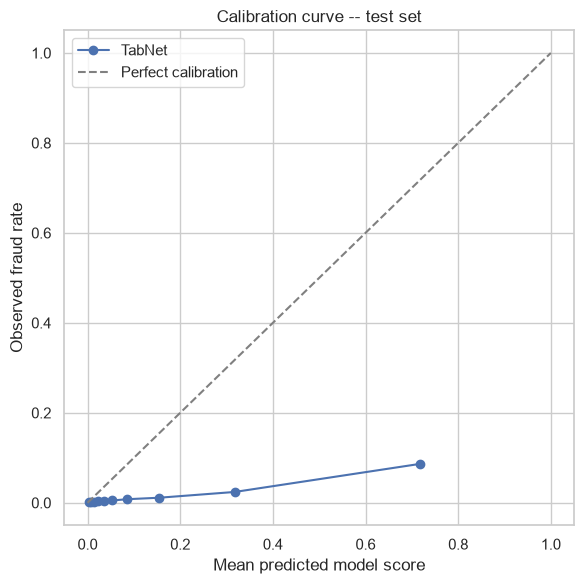

IMPORTANT: Unless calibration is close to the diagonal, interpret SHAP/IG values as changes
in the model's fraud-class output score, not as calibrated changes in real-world probability.


In [13]:
# Probability calibration diagnostics and logit-output helpers.
# Because the model was trained under strong imbalance handling, its probability outputs may rank
# cases well but still be poorly calibrated. Therefore, SHAP expected values should be interpreted
# as model-output scores unless calibration diagnostics support probability interpretation.

class TabNetLogitWrapper(nn.Module):
    """forward(x) -> raw logits tensor of shape (batch, n_classes)."""
    def __init__(self, tabnet_network):
        super().__init__()
        self.tabnet_network = tabnet_network

    def forward(self, x):
        logits, _ = self.tabnet_network(x)
        return logits


logit_model = TabNetLogitWrapper(clf.network)
logit_model.eval()


def predict_logit_fn(X):
    """Numpy array -> raw fraud-class logit, useful for XAI robustness checks."""
    X_t = torch.tensor(np.asarray(X, dtype=np.float32), dtype=torch.float32)
    with torch.no_grad():
        logits = logit_model(X_t)
    return logits[:, 1].detach().numpy()


def calibration_report(split_name, X_split, y_split, max_n=50000):
    """Print calibration diagnostics on a bounded sample for runtime safety."""
    rng = np.random.RandomState(RANDOM_STATE)
    if X_split.shape[0] > max_n:
        idx = rng.choice(X_split.shape[0], size=max_n, replace=False)
        X_eval = X_split[idx]
        y_eval = np.asarray(y_split)[idx]
    else:
        X_eval = X_split
        y_eval = np.asarray(y_split)
    p = predict_proba_fn(X_eval)
    out = {
        "split": split_name,
        "n": len(y_eval),
        "true_fraud_rate": float(np.mean(y_eval)),
        "mean_predicted_score": float(np.mean(p)),
        "auc": float(roc_auc_score(y_eval, p)),
        "brier": float(brier_score_loss(y_eval, p)),
    }
    return out


calibration_summary = pd.DataFrame([
    calibration_report("train_sample", X_train_proc, y_train),
    calibration_report("validation", X_val_proc, y_val),
    calibration_report("test", X_test_proc, y_test),
])
display(calibration_summary)

# Calibration curve on the test split.
test_probs = predict_proba_fn(X_test_proc)
frac_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="quantile")
plt.figure(figsize=(6, 6))
plt.plot(mean_pred, frac_pos, marker="o", label="TabNet")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted model score")
plt.ylabel("Observed fraud rate")
plt.title("Calibration curve -- test set")
plt.legend()
plt.tight_layout()
plt.show()

print("IMPORTANT: Unless calibration is close to the diagonal, interpret SHAP/IG values as changes")
print("in the model's fraud-class output score, not as calibrated changes in real-world probability.")


In [14]:
# Optional calibrated-model comparison.
# This does NOT replace the original TabNet model used for the main XAI benchmark.
# It quantifies how much probability calibration would change the interpretation of model scores.

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

p_val_uncal = predict_proba_fn(X_val_proc)
p_test_uncal = predict_proba_fn(X_test_proc)

# Platt scaling: monotonic logistic calibration on validation scores.
platt_calibrator = LogisticRegression(solver="lbfgs", max_iter=1000)
platt_calibrator.fit(p_val_uncal.reshape(-1, 1), y_val)
p_test_platt = platt_calibrator.predict_proba(p_test_uncal.reshape(-1, 1))[:, 1]

# Isotonic calibration: flexible monotonic calibration. Useful as a diagnostic;
# can overfit if validation data is small, but here validation is large.
isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")
isotonic_calibrator.fit(p_val_uncal, y_val)
p_test_iso = isotonic_calibrator.predict(p_test_uncal)

calibration_comparison = pd.DataFrame([
    {
        "score_type": "Original TabNet score",
        "mean_score_or_prob": p_test_uncal.mean(),
        "true_test_fraud_rate": y_test.mean(),
        "auc": roc_auc_score(y_test, p_test_uncal),
        "brier": brier_score_loss(y_test, p_test_uncal),
    },
    {
        "score_type": "Platt-calibrated probability",
        "mean_score_or_prob": p_test_platt.mean(),
        "true_test_fraud_rate": y_test.mean(),
        "auc": roc_auc_score(y_test, p_test_platt),
        "brier": brier_score_loss(y_test, p_test_platt),
    },
    {
        "score_type": "Isotonic-calibrated probability",
        "mean_score_or_prob": p_test_iso.mean(),
        "true_test_fraud_rate": y_test.mean(),
        "auc": roc_auc_score(y_test, p_test_iso),
        "brier": brier_score_loss(y_test, p_test_iso),
    },
]).round(6)
display(calibration_comparison)

# Helper functions if calibrated probabilities are needed for reporting/calibrated curves later.
def predict_proba_platt_fn(X):
    base = predict_proba_fn(X)
    return platt_calibrator.predict_proba(base.reshape(-1, 1))[:, 1]


def predict_proba_isotonic_fn(X):
    base = predict_proba_fn(X)
    return isotonic_calibrator.predict(base)

print("Decision rule for the thesis:")
print("- Main XAI results explain the original TabNet fraud score, because that is the model actually trained/evaluated.")
print("- Calibrated probabilities may be reported separately for risk communication, but attribution values should not be called calibrated probability changes unless recalculated on a calibrated wrapper.")


,score_type,mean_score_or_prob,true_test_fraud_rate,auc,brier
0,Original TabNet score,0.141013,0.014746,0.849977,0.066666
1,Platt-calibrated probability,0.011498,0.014746,0.849977,0.013605
2,Isotonic-calibrated probability,0.011284,0.014746,0.848436,0.013527


Decision rule for the thesis:
- Main XAI results explain the original TabNet fraud score, because that is the model actually trained/evaluated.
- Calibrated probabilities may be reported separately for risk communication, but attribution values should not be called calibrated probability changes unless recalculated on a calibrated wrapper.


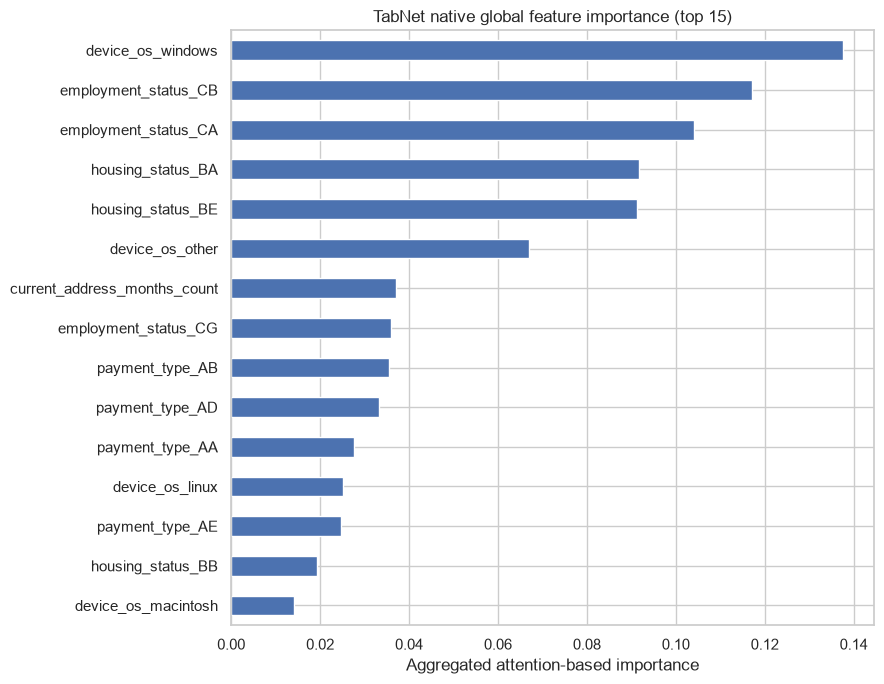

In [15]:
top_n = 15
plt.figure(figsize=(9, 7))
tabnet_global_importance.sort_values(ascending=False).head(top_n).iloc[::-1].plot(
    kind="barh", color="#4C72B0"
)
plt.title("TabNet native global feature importance (top 15)")
plt.xlabel("Aggregated attention-based importance")
plt.tight_layout()
plt.show()


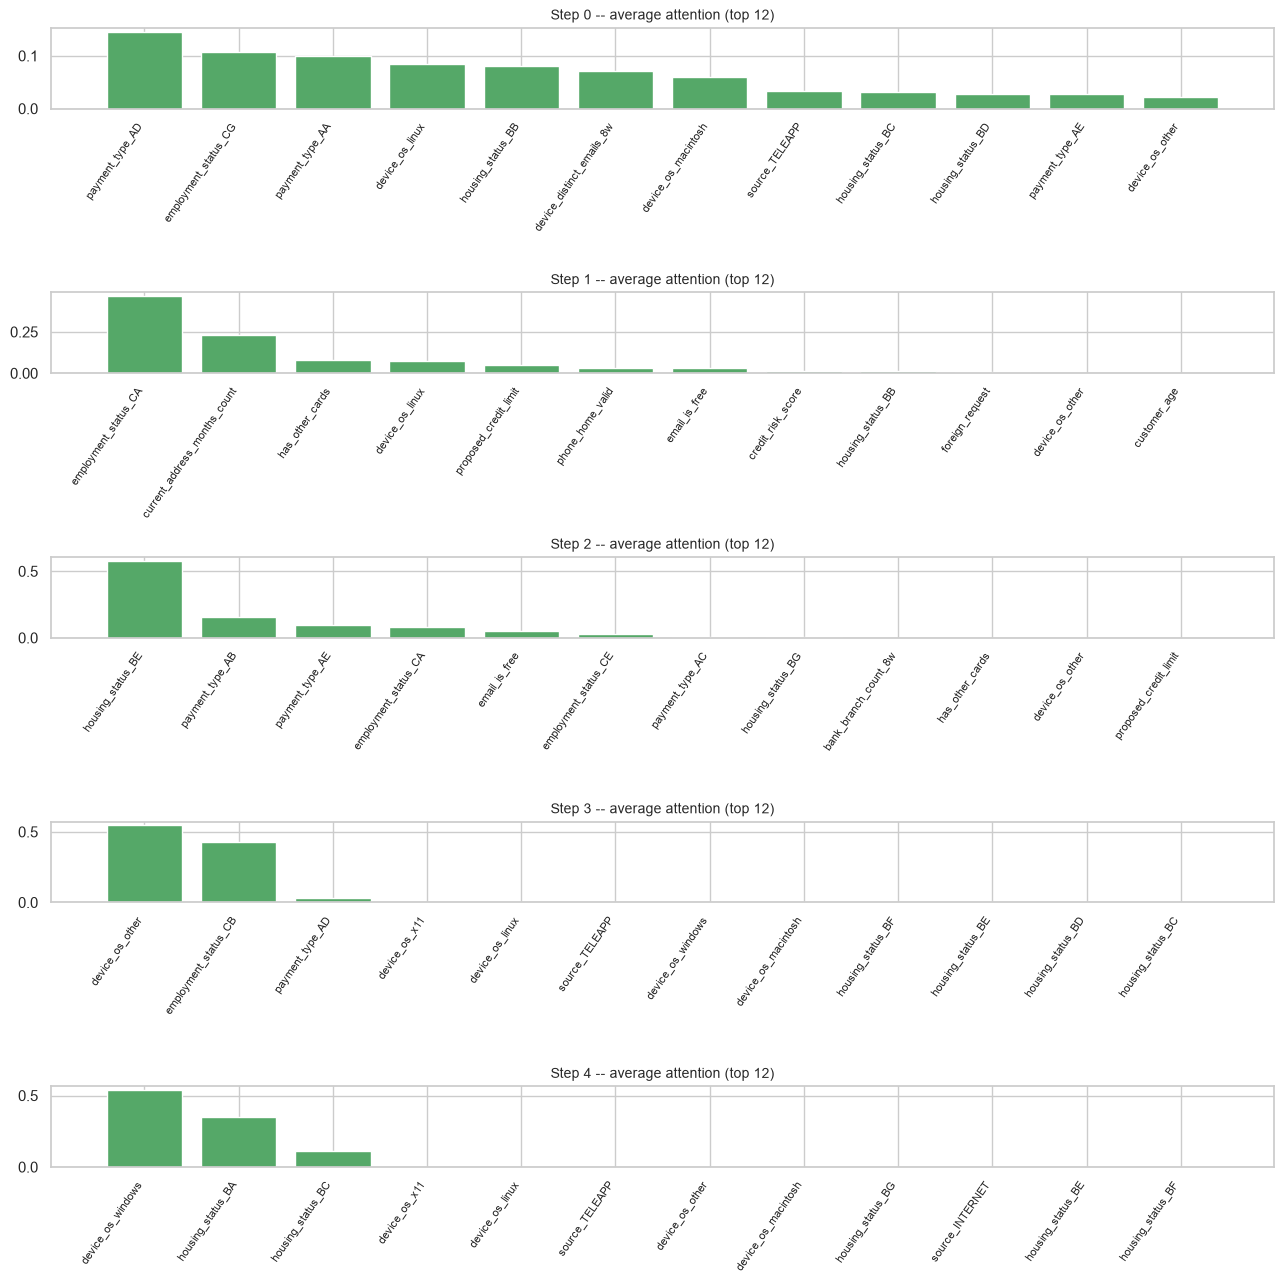

In [16]:
# Per-step attention: average mask per step, over the explanation subset
fig, axes = plt.subplots(n_native_steps, 1, figsize=(13, 2.6 * n_native_steps))
if n_native_steps == 1:
    axes = [axes]

for step in range(n_native_steps):
    avg_mask = native_masks[step].mean(axis=0)
    top_idx = np.argsort(avg_mask)[::-1][:12]
    axes[step].bar(range(len(top_idx)), avg_mask[top_idx], color="#55A868")
    axes[step].set_xticks(range(len(top_idx)))
    axes[step].set_xticklabels([feature_names[i] for i in top_idx], rotation=55, ha="right", fontsize=8)
    axes[step].set_title(f"Step {step} -- average attention (top 12)", fontsize=10)

plt.tight_layout()
plt.show()

# Expected result: a recap of Section 5 from the training notebook -- different steps
# should focus on at least partially different feature subsets. This is the interpretability
# "for free" that TabNet provides natively, and the yardstick the post-hoc methods below
# are measured against.


## 3. SHAP -- `KernelExplainer`

**Goal:** apply SHAP's model-agnostic `KernelExplainer` — it treats the model as a pure
black box (only needs `predict_proba_fn`), which makes it slow (many perturbation samples
per instance) but universally applicable regardless of model architecture.

We explain `predict_proba_fn`, i.e. the probability of `fraud_bool = 1`, against the
K-Means-summarized background (`shap_background`, 50 points) exported from the training
notebook, on the first `N_KERNEL_LIME_INSTANCES` rows of the fixed explanation subset.

**Expected result:** a `(N_KERNEL_LIME_INSTANCES, N_FEATURES)` SHAP-value matrix, an
`expected_value` (the background's average predicted probability -- the SHAP "starting
point" every explanation is relative to), and enough structure to build beeswarm/waterfall/
force plots.

**What to check (next cell):** The printed shape should be
`(N_KERNEL_LIME_INSTANCES, N_FEATURES)`, and `Expected value` should be a plausible
probability (not exactly 0 or 1) now that Section 1.1's background fix has been applied.


In [17]:
kernel_subset = X_explain[:N_KERNEL_LIME_INSTANCES]

kernel_explainer = shap.KernelExplainer(predict_proba_fn, shap_background)

shap_values_kernel = kernel_explainer.shap_values(
    kernel_subset, nsamples=KERNEL_NSAMPLES
)
# shap_values_kernel: (N_KERNEL_LIME_INSTANCES, N_FEATURES) for this single-output function
shap_values_kernel = np.array(shap_values_kernel)
if shap_values_kernel.ndim == 3:      # some shap versions return (1, n, d) for single-output fns
    shap_values_kernel = shap_values_kernel[0]

kernel_expected_value = kernel_explainer.expected_value
if isinstance(kernel_expected_value, (list, np.ndarray)):
    kernel_expected_value = float(np.ravel(kernel_expected_value)[0])

print("SHAP KernelExplainer values shape:", shap_values_kernel.shape)
print("Expected model output on background (fraud-class score/probability, not necessarily calibrated):", round(kernel_expected_value, 4))


100%|██████████| 100/100 [00:51<00:00,  1.94it/s]

SHAP KernelExplainer values shape: (100, 48)
Expected model output on background (fraud-class score/probability, not necessarily calibrated): 0.2481


### 3.1 Global feature importance (KernelExplainer)

Standard SHAP global importance: mean absolute SHAP value per feature, across the explained
instances.

**What to check:** the printed top-15 table should match the bar chart above it. Keep this
ranking in mind when you reach Sections 4.1/5.1/6.1 -- comparing them informally here, ahead
of the formal Section 7 comparison, helps build intuition for what a "high agreement" or
"low agreement" result should look like.


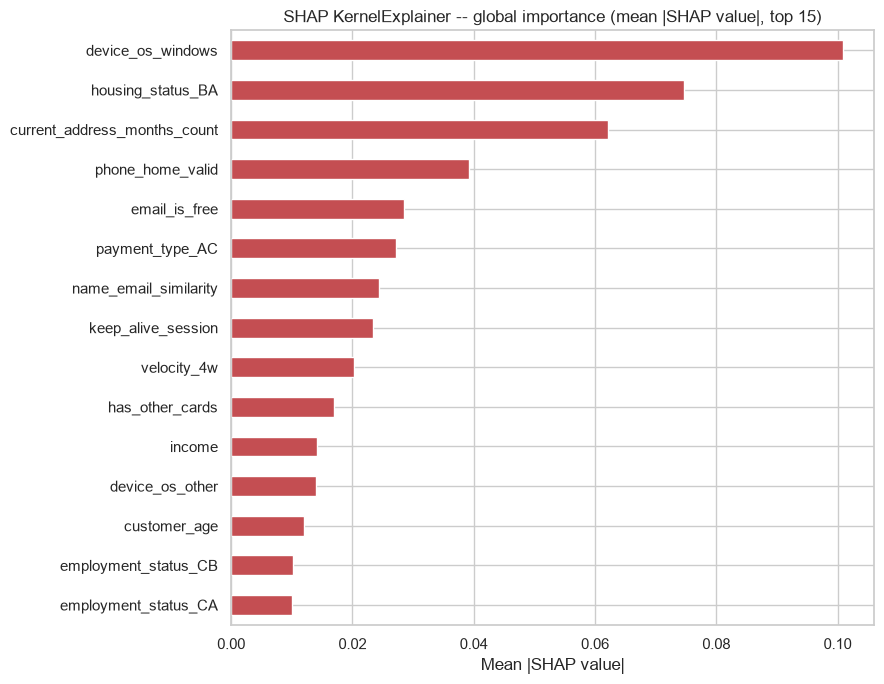

device_os_windows               0.100956
housing_status_BA               0.074597
current_address_months_count    0.062141
phone_home_valid                0.039176
email_is_free                   0.028444
payment_type_AC                 0.027110
name_email_similarity           0.024448
keep_alive_session              0.023440
velocity_4w                     0.020254
has_other_cards                 0.016950
income                          0.014183
device_os_other                 0.014057
customer_age                    0.012025
employment_status_CB            0.010274
employment_status_CA            0.009948
dtype: float64

In [18]:
shap_kernel_global = pd.Series(
    np.abs(shap_values_kernel).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
shap_kernel_global.head(15).iloc[::-1].plot(kind="barh", color="#C44E52")
plt.title("SHAP KernelExplainer -- global importance (mean |SHAP value|, top 15)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

shap_kernel_global.head(15)


### 3.2 Beeswarm plot (global spread of SHAP values)

The beeswarm plot shows, for each top feature, how its SHAP value spreads across
instances, colored by the feature's own value — this reveals not just *which* features
matter, but *how* (e.g. "high income pushes the prediction toward fraud").

**What to check:** each row should show a reasonably clear color split (e.g. one color
clustered left, the other right) for the top features. A top-ranked feature with no color
separation means SHAP isn't finding a consistent *direction* of effect for it, even though
its magnitude is large.


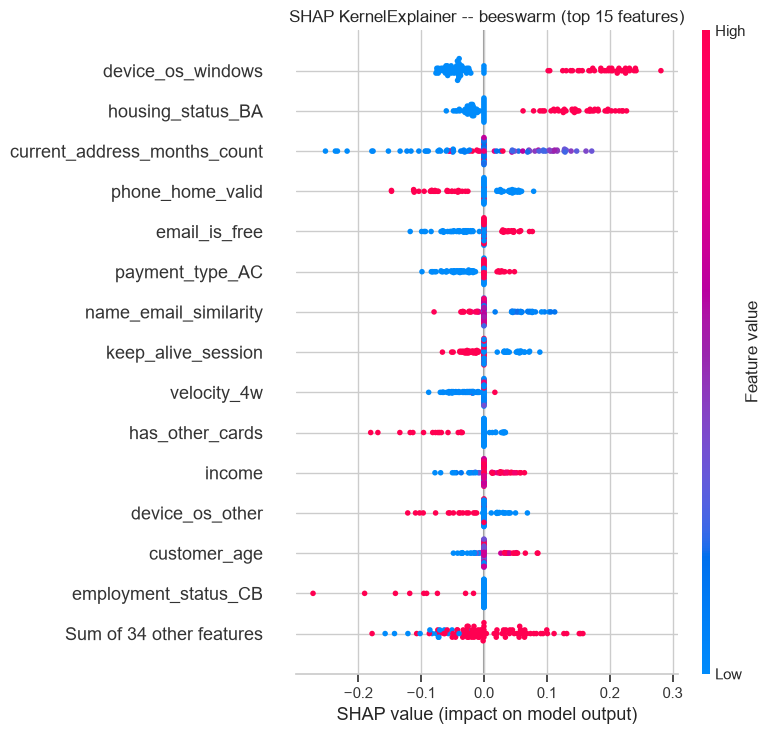

In [19]:
shap_explanation_kernel = shap.Explanation(
    values=shap_values_kernel,
    base_values=np.full(shap_values_kernel.shape[0], kernel_expected_value),
    data=kernel_subset,
    feature_names=feature_names,
)

shap.plots.beeswarm(shap_explanation_kernel, max_display=15, show=False)
plt.title("SHAP KernelExplainer -- beeswarm (top 15 features)")
plt.tight_layout()
plt.show()


### 3.3 Waterfall chart (single instance)

A waterfall plot breaks down one specific prediction: starting from the background's
average P(fraud) (`expected_value`), it shows how each feature pushes the prediction up or
down until it reaches the model's actual output for that instance.

We use **instance 0** of the explanation subset as the running example throughout this
notebook, so all methods (SHAP, LIME, Integrated Gradients, TabNet-native) can be compared
on the exact same "solicitud de cuenta".

**What to check:** the printed `Model P(fraud)` for the example instance should match the
waterfall's final cumulative value, and the bars should visibly sum from `Expected value`
(background average) up (or down) to that final prediction.


In [20]:
# Strong robustness check: SHAP KernelExplainer on raw fraud logit instead of softmax probability.
# This helps determine whether feature rankings are an artifact of probability saturation/calibration.

RUN_LOGIT_KERNEL_SHAP = True
N_LOGIT_KERNEL_INSTANCES = 50 if not QUICK_MODE else 20
LOGIT_KERNEL_NSAMPLES = 200 if not QUICK_MODE else 80

if RUN_LOGIT_KERNEL_SHAP:
    logit_subset = X_explain[:N_LOGIT_KERNEL_INSTANCES]
    logit_kernel_explainer = shap.KernelExplainer(predict_logit_fn, shap_background)
    shap_values_kernel_logit = logit_kernel_explainer.shap_values(
        logit_subset,
        nsamples=LOGIT_KERNEL_NSAMPLES,
    )
    shap_values_kernel_logit = np.array(shap_values_kernel_logit)
    if shap_values_kernel_logit.ndim == 3:
        shap_values_kernel_logit = shap_values_kernel_logit[0]

    shap_kernel_logit_global = pd.Series(
        np.abs(shap_values_kernel_logit).mean(axis=0), index=feature_names
    ).sort_values(ascending=False)

    rank_corr_prob_vs_logit, _ = spearmanr(
        shap_kernel_global.reindex(feature_names),
        shap_kernel_logit_global.reindex(feature_names),
    )
    print("SHAP Kernel probability-vs-logit global ranking Spearman:", round(rank_corr_prob_vs_logit, 3))
    display(pd.DataFrame({
        "probability_target_top15": shap_kernel_global.head(15).index,
        "logit_target_top15": shap_kernel_logit_global.head(15).index,
    }))
else:
    print("Logit Kernel SHAP skipped. Set RUN_LOGIT_KERNEL_SHAP=True to run it.")


100%|██████████| 50/50 [00:07<00:00,  6.26it/s]

SHAP Kernel probability-vs-logit global ranking Spearman: 0.823


,probability_target_top15,logit_target_top15
0,device_os_windows,housing_status_BA
1,housing_status_BA,device_os_other
2,current_address_months_count,phone_home_valid
3,phone_home_valid,device_os_windows
4,email_is_free,payment_type_AC
5,payment_type_AC,customer_age
6,name_email_similarity,housing_status_BE
7,keep_alive_session,name_email_similarity
8,velocity_4w,current_address_months_count
9,has_other_cards,income


Example instance -- true label: FRAUD
Model P(fraud) for this instance: 0.8166


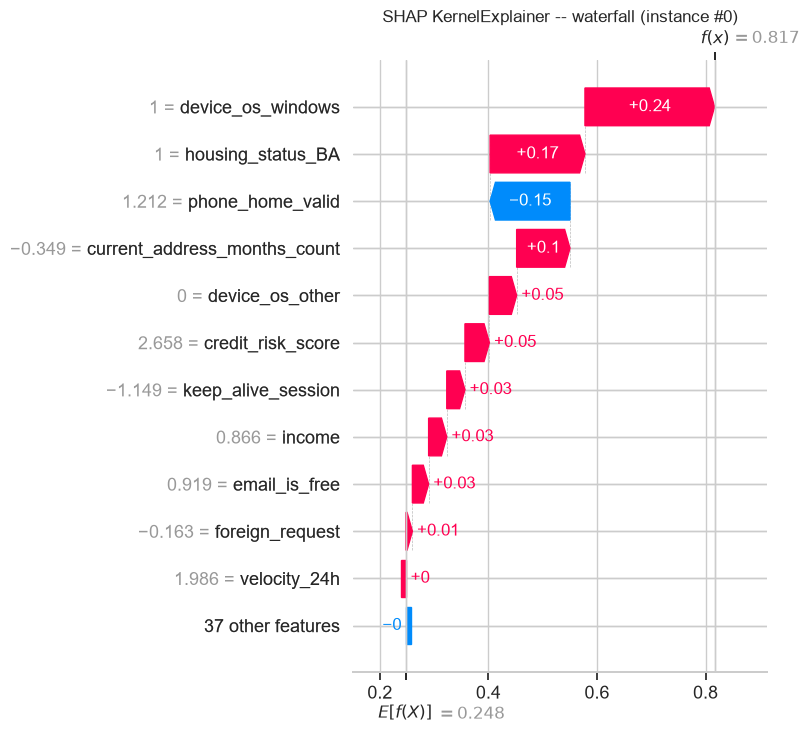

In [21]:
EXAMPLE_IDX = 0  # index within X_explain / kernel_subset -- used consistently below

print("Example instance -- true label:", "FRAUD" if y_explain[EXAMPLE_IDX] == 1 else "legit")
print("Model P(fraud) for this instance:", round(predict_proba_fn(X_explain[EXAMPLE_IDX:EXAMPLE_IDX+1])[0], 4))

shap.plots.waterfall(shap_explanation_kernel[EXAMPLE_IDX], max_display=12, show=False)
plt.title(f"SHAP KernelExplainer -- waterfall (instance #{EXAMPLE_IDX})")
plt.tight_layout()
plt.show()


### 3.4 Force plot ("fuerza por instancia")

The force plot is the compact, single-row version of the waterfall: features pushing the
prediction up (toward fraud) in red, features pushing it down (toward legit) in blue.

**What to check:** the red/blue split here should match the waterfall's positive/negative
bars for the same instance -- both are two views of the same underlying SHAP values.


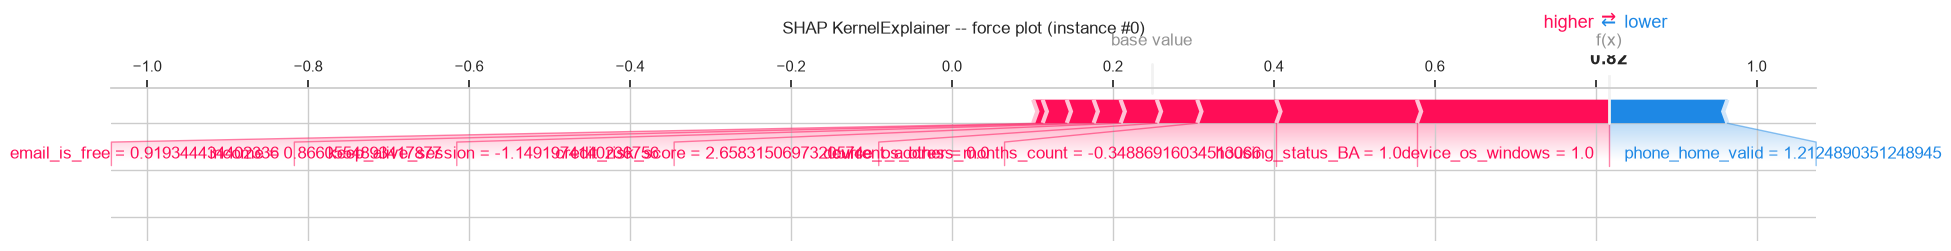

In [22]:
shap.plots.force(
    kernel_expected_value,
    shap_values_kernel[EXAMPLE_IDX],
    kernel_subset[EXAMPLE_IDX],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
)
plt.title(f"SHAP KernelExplainer -- force plot (instance #{EXAMPLE_IDX})", y=1.3)
plt.tight_layout()
plt.show()


## 4. SHAP -- `GradientExplainer`

**Goal:** apply SHAP's gradient-based explainer, which uses `torch_model`'s gradients
directly instead of black-box perturbations. It's much faster than `KernelExplainer`
(no repeated `predict_proba` calls), so we run it on the **full** 200-instance explanation
subset rather than the smaller `N_KERNEL_LIME_INSTANCES`.

**Expected result:** SHAP values that should be directionally similar to
`KernelExplainer`'s (both are approximating the same underlying Shapley values, via
different algorithms), computed in a fraction of the time.

**What to check (next cell):** this should run in seconds, not minutes -- if it's slow,
something is off with tensor devices/shapes. As an early, informal sanity check, compare the
resulting values against `shap_values_kernel` from Section 3 before the formal agreement
check in Section 4.3.


In [23]:
background_tensor = torch.tensor(shap_background, dtype=torch.float32)
explain_tensor = torch.tensor(X_explain, dtype=torch.float32)

gradient_explainer = shap.GradientExplainer(torch_model, background_tensor)

shap_values_gradient_raw = gradient_explainer.shap_values(explain_tensor)
shap_values_gradient_raw = np.array(shap_values_gradient_raw)

# GradientExplainer returns one array per output class; we keep the fraud class (index 1)
if shap_values_gradient_raw.ndim == 3:
    # shape could be (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes)
    if shap_values_gradient_raw.shape[0] == 2:
        shap_values_gradient = shap_values_gradient_raw[1]
    else:
        shap_values_gradient = shap_values_gradient_raw[..., 1]
else:
    shap_values_gradient = shap_values_gradient_raw

print("SHAP GradientExplainer values shape:", shap_values_gradient.shape)


SHAP GradientExplainer values shape: (200, 48)


### 4.1 Global feature importance (GradientExplainer)

**What to check:** compare this ranking, feature by feature, against Section 3.1's
KernelExplainer ranking. Broad agreement here is an informal preview of what Section 4.3
measures with an actual number.


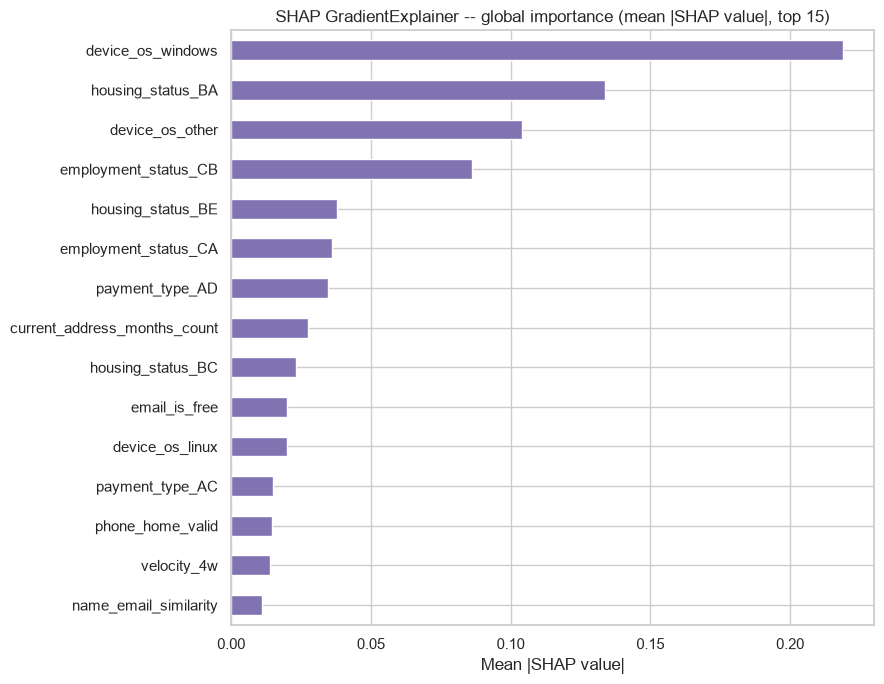

In [24]:
shap_gradient_global = pd.Series(
    np.abs(shap_values_gradient).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
shap_gradient_global.head(15).iloc[::-1].plot(kind="barh", color="#8172B2")
plt.title("SHAP GradientExplainer -- global importance (mean |SHAP value|, top 15)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()


### 4.2 Beeswarm plot (GradientExplainer)

**What to check:** compare the color pattern against the KernelExplainer beeswarm (Section
3.2) for the same top features -- consistent color direction across both plots means the two
SHAP variants agree not just on *which* features matter but *how* they push the prediction.


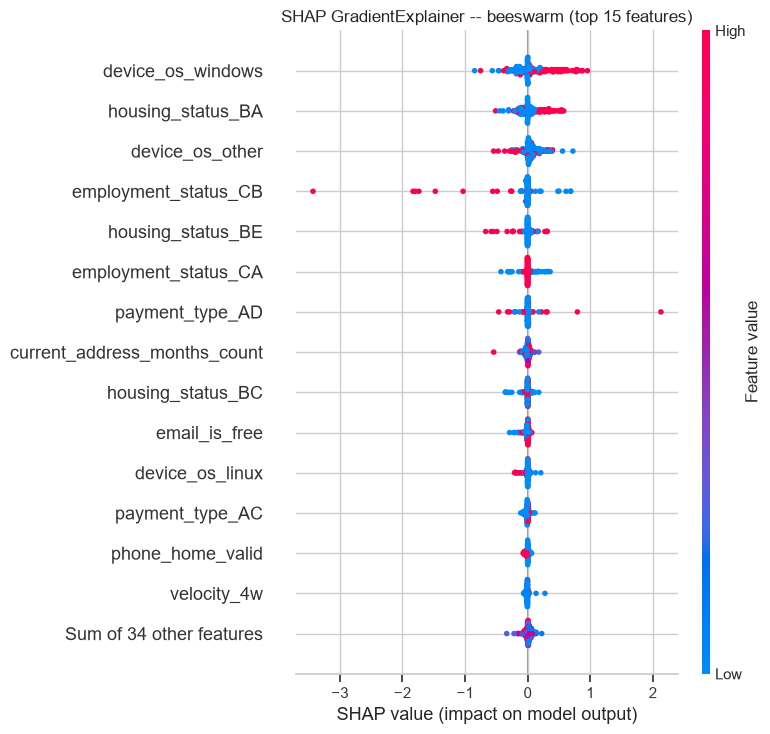

In [25]:
shap_explanation_gradient = shap.Explanation(
    values=shap_values_gradient,
    base_values=np.full(shap_values_gradient.shape[0], predict_proba_fn(shap_background).mean()),
    data=X_explain,
    feature_names=feature_names,
)

shap.plots.beeswarm(shap_explanation_gradient, max_display=15, show=False)
plt.title("SHAP GradientExplainer -- beeswarm (top 15 features)")
plt.tight_layout()
plt.show()


### 4.3 KernelExplainer vs. GradientExplainer sanity check

Since both approximate the same underlying Shapley values, their **global rankings**
should be strongly correlated even though the exact numbers differ (different
approximation algorithms). We check this with Spearman rank correlation on the features
common to both comparisons.

**What to check:** the printed Spearman correlation should be clearly positive (e.g. above
0.5-0.7). A low or negative value would suggest one of the two SHAP computations is
unreliable and worth re-checking before trusting either one's ranking.


In [26]:
# Compare Kernel SHAP and Gradient SHAP on the SAME instances.
# Kernel SHAP is only computed on kernel_subset, while Gradient SHAP was computed on all X_explain.
# Using the same first N rows avoids an apples-to-oranges comparison.
shap_gradient_global_on_kernel_subset = pd.Series(
    np.abs(shap_values_gradient[:N_KERNEL_LIME_INSTANCES]).mean(axis=0),
    index=feature_names,
).sort_values(ascending=False)

rank_corr, _ = spearmanr(
    shap_kernel_global.reindex(feature_names),
    shap_gradient_global_on_kernel_subset.reindex(feature_names),
)
print(f"Spearman rank correlation between KernelExplainer and GradientExplainer "
      f"global importances on the same {N_KERNEL_LIME_INSTANCES} instances: {rank_corr:.3f}")


Spearman rank correlation between KernelExplainer and GradientExplainer global importances on the same 100 instances: 0.805


## 5. LIME (`LimeTabularExplainer`)

**Goal:** apply LIME, which explains each instance by fitting a local, interpretable
(linear) surrogate model around it, using perturbed samples weighted by proximity to the
original instance.

Since all our preprocessing (imputation, one-hot encoding, scaling) already happened
upstream, `X_train_res` is fully numeric -- LIME is used in pure **continuous-feature
mode** (no `categorical_features` argument needed).

LIME explains one instance at a time, so we loop over the same
`N_KERNEL_LIME_INSTANCES`-instance subset used for `KernelExplainer`, and assemble the
per-feature weights into a single `(N_KERNEL_LIME_INSTANCES, N_FEATURES)` matrix for
global/comparison analysis.

**What to check (next cell):** this loop fits one LIME surrogate model per instance and can
be slow for large `LIME_NUM_SAMPLES` . `lime_values` should end up with no all-zero rows;
an all-zero row would mean LIME's surrogate fit silently failed for that instance.


In [27]:
assert X_train_proc.shape[1] == N_FEATURES

lime_explainer = LimeTabularExplainer(
    training_data=X_train_proc,   # FIX: real, non-SMOTE distribution; do NOT use X_train_res here.
    feature_names=feature_names,
    class_names=["legit", "fraud"],
    mode="classification",
    discretize_continuous=False,   # keep features continuous -> weights map 1:1 to feature_names
    random_state=RANDOM_STATE,
)

lime_values = np.zeros((N_KERNEL_LIME_INSTANCES, N_FEATURES))
lime_explanations = []  # keep the raw Explanation objects too, for local plots later

for i in range(N_KERNEL_LIME_INSTANCES):
    exp = lime_explainer.explain_instance(
        X_explain[i],
        predict_fn=lambda x: clf.predict_proba(x),   # LIME needs both class probabilities
        num_features=N_FEATURES,
        num_samples=LIME_NUM_SAMPLES,
    )
    lime_explanations.append(exp)
    for feat_idx, weight in exp.as_map()[1]:   # class index 1 = fraud
        lime_values[i, feat_idx] = weight

print("LIME values shape:", lime_values.shape)


LIME values shape: (100, 48)


### 5.1 Global feature importance (LIME)

**What to check:** LIME's top features often differ more from SHAP/IG than SHAP and IG
differ from each other -- that's expected, since LIME is a fundamentally different (local
linear surrogate) approach, not automatically a sign of a bug.


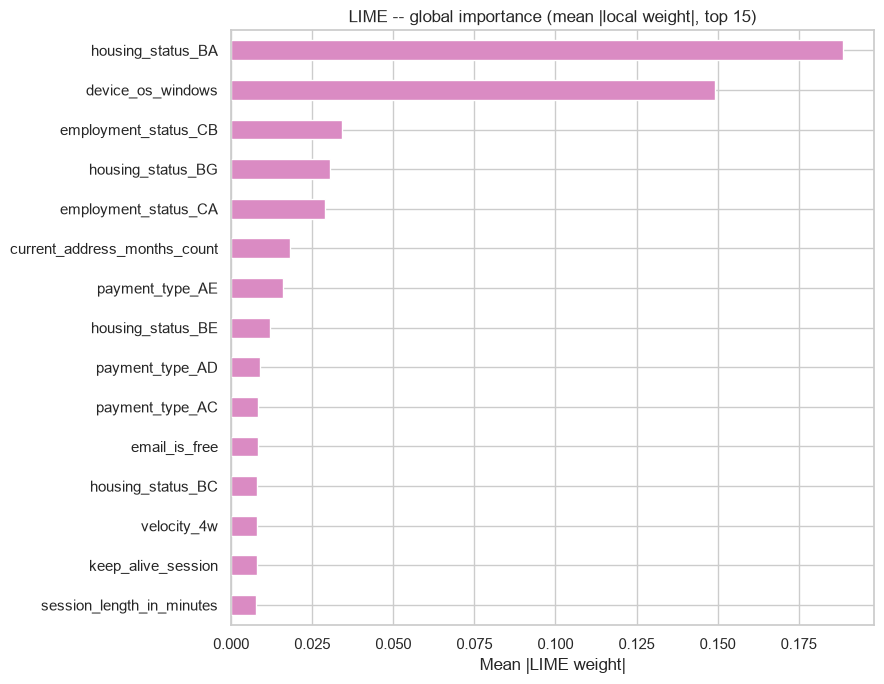

In [28]:
lime_global = pd.Series(
    np.abs(lime_values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
lime_global.head(15).iloc[::-1].plot(kind="barh", color="#DA8BC3")
plt.title("LIME -- global importance (mean |local weight|, top 15)")
plt.xlabel("Mean |LIME weight|")
plt.tight_layout()
plt.show()


### 5.2 Local explanation for the running example instance

LIME's native plot for a single instance, for the same `EXAMPLE_IDX` used in Section 3.3 /
3.4, so it can be visually compared against the SHAP waterfall/force plots.

**What to check:** compare LIME's top features and their signs for this instance against the
SHAP waterfall/force plots (Sections 3.3/3.4) for the same `EXAMPLE_IDX`.


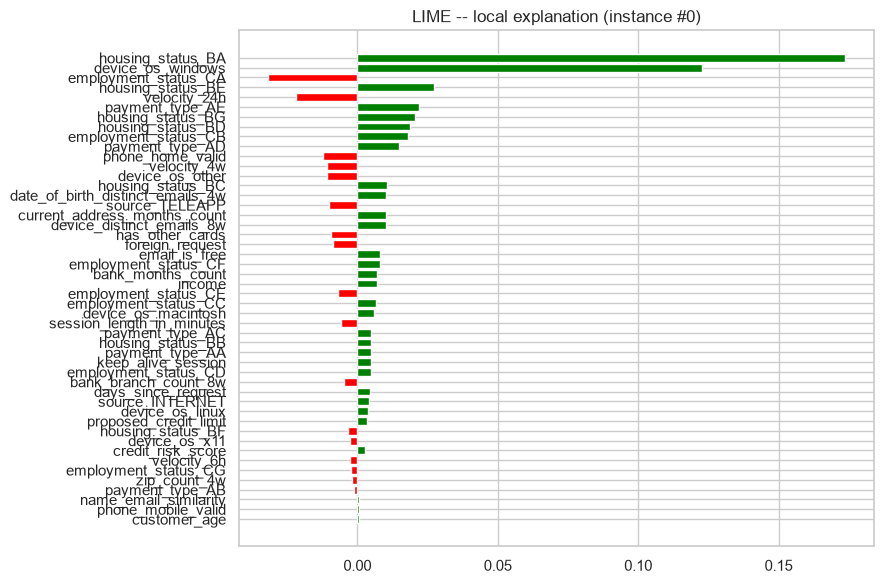

In [29]:
fig = lime_explanations[EXAMPLE_IDX].as_pyplot_figure(label=1)
fig.set_size_inches(9, 6)
plt.title(f"LIME -- local explanation (instance #{EXAMPLE_IDX})")
plt.tight_layout()
plt.show()


## 6. Integrated Gradients (Captum)

**Goal:** apply Integrated Gradients, an axiomatic attribution method that integrates
gradients along a straight-line path from a baseline (here: the all-zero vector, which in
standardized feature space represents the *feature-wise mean* -- a neutral, uninformative
input) to the actual instance.

Like `GradientExplainer`, this is fast (gradient-based), so we run it on the **full**
200-instance explanation subset.

**What to check (next cell):** `Mean |convergence delta|` should be small (close to 0) --
Integrated Gradients has a mathematical completeness guarantee, so a large delta signals a
numerical issue (e.g. too few integration `n_steps` -- not to be confused with TabNet's own
`n_steps` hyperparameter) rather than a modeling problem.


In [30]:
integrated_gradients = IntegratedGradients(torch_model)
integrated_gradients_logit = IntegratedGradients(logit_model)

# IMPORTANT FIX:
# Do not use an all-zero baseline in a one-hot encoded tabular space: it represents
# "no category" for every categorical variable and is off-manifold. Instead, use several
# REAL training rows as references and average the IG attributions (Expected-Gradients style).
# Use more integration steps and Gauss-Legendre quadrature to improve the completeness diagnostic.
N_IG_BASELINES = 5 if QUICK_MODE else 20
IG_N_STEPS = 80 if QUICK_MODE else 200
ig_baseline_refs = xai_baseline_pool[:min(N_IG_BASELINES, xai_baseline_pool.shape[0])].astype(np.float32)


def integrated_gradients_real_baselines(model_for_ig, X_np, baseline_refs, target=1,
                                        n_steps=IG_N_STEPS, method="gausslegendre"):
    """Average Integrated Gradients over multiple real reference rows.

    Returns attributions, absolute deltas, and relative deltas. Relative delta is computed
    against the model-output difference between input and baseline for each reference.
    """
    X_np = X_np.astype(np.float32)
    ig_obj = IntegratedGradients(model_for_ig)
    attrs, deltas_abs, deltas_rel = [], [], []
    for b in baseline_refs:
        x_tensor = torch.tensor(X_np, dtype=torch.float32, requires_grad=True)
        baseline_np = np.repeat(b.reshape(1, -1), X_np.shape[0], axis=0)
        baseline_tensor = torch.tensor(baseline_np, dtype=torch.float32)
        attr, delta = ig_obj.attribute(
            x_tensor,
            baselines=baseline_tensor,
            target=target,
            n_steps=n_steps,
            method=method,
            return_convergence_delta=True,
        )
        with torch.no_grad():
            out_x = model_for_ig(x_tensor)[:, target]
            out_b = model_for_ig(baseline_tensor)[:, target]
            denom = torch.abs(out_x - out_b).detach().numpy() + 1e-8
        delta_np = delta.detach().numpy()
        attrs.append(attr.detach().numpy())
        deltas_abs.append(np.abs(delta_np))
        deltas_rel.append(np.abs(delta_np) / denom)
    return np.mean(attrs, axis=0), np.concatenate(deltas_abs), np.concatenate(deltas_rel)


ig_values, ig_delta_abs_all, ig_delta_rel_all = integrated_gradients_real_baselines(
    torch_model,
    X_explain,
    ig_baseline_refs,
    target=1,
    n_steps=IG_N_STEPS,
)

# Strong recommended check: logit-target IG. This is often more numerically meaningful than
# probability-target IG when softmax outputs are poorly calibrated or saturated.
ig_values_logit, ig_logit_delta_abs_all, ig_logit_delta_rel_all = integrated_gradients_real_baselines(
    logit_model,
    X_explain,
    ig_baseline_refs,
    target=1,
    n_steps=IG_N_STEPS,
)

ig_global_logit = pd.Series(np.abs(ig_values_logit).mean(axis=0), index=feature_names).sort_values(ascending=False)
ig_prob_vs_logit_corr, _ = spearmanr(ig_global.reindex(feature_names) if 'ig_global' in globals() else pd.Series(np.abs(ig_values).mean(axis=0), index=feature_names).reindex(feature_names),
                                     ig_global_logit.reindex(feature_names))

print("Integrated Gradients values shape:", ig_values.shape)
print("Number of real IG baselines:", ig_baseline_refs.shape[0])
print("IG integration steps:", IG_N_STEPS)
print("Probability-target IG mean |delta|:", float(np.mean(ig_delta_abs_all)))
print("Probability-target IG median relative delta:", float(np.median(ig_delta_rel_all)))
print("Logit-target IG mean |delta|:", float(np.mean(ig_logit_delta_abs_all)))
print("Logit-target IG median relative delta:", float(np.median(ig_logit_delta_rel_all)))
print("IG probability-vs-logit global ranking Spearman:", round(float(ig_prob_vs_logit_corr), 3))


Integrated Gradients values shape: (200, 48)
Number of real IG baselines: 20
IG integration steps: 200
Probability-target IG mean |delta|: 0.045436494052410126
Probability-target IG median relative delta: 0.023501046001911163
Logit-target IG mean |delta|: 0.37595313787460327
Logit-target IG median relative delta: 0.01730942726135254
IG probability-vs-logit global ranking Spearman: 0.924


### 6.1 Global feature importance (Integrated Gradients)

**What to check:** compare this ranking against Section 4.1 (SHAP GradientExplainer) -- both
are gradient-based, so stronger agreement between these two than either has with LIME or
KernelExplainer would be the expected pattern.


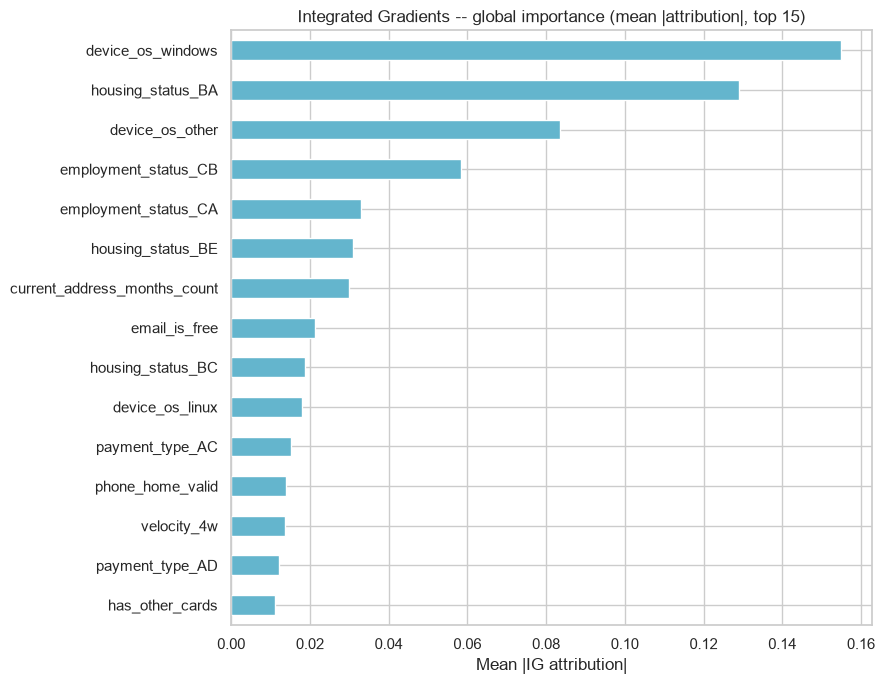

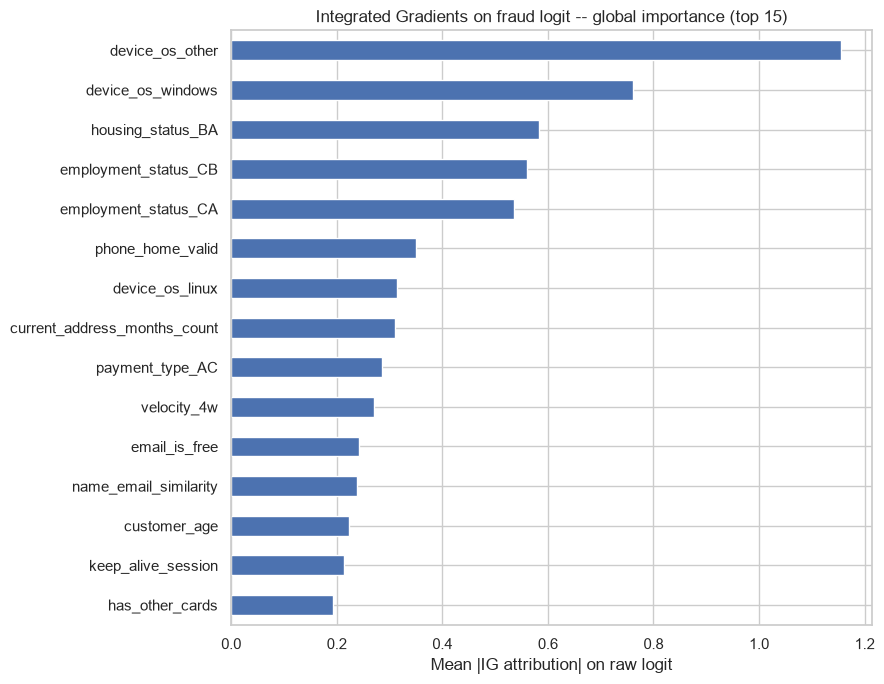

,IG_probability_top15,IG_logit_top15
0,device_os_windows,device_os_other
1,housing_status_BA,device_os_windows
2,device_os_other,housing_status_BA
3,employment_status_CB,employment_status_CB
4,employment_status_CA,employment_status_CA
5,housing_status_BE,phone_home_valid
6,current_address_months_count,device_os_linux
7,email_is_free,current_address_months_count
8,housing_status_BC,payment_type_AC
9,device_os_linux,velocity_4w


In [31]:
ig_global = pd.Series(
    np.abs(ig_values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
ig_global.head(15).iloc[::-1].plot(kind="barh", color="#64B5CD")
plt.title("Integrated Gradients -- global importance (mean |attribution|, top 15)")
plt.xlabel("Mean |IG attribution|")
plt.tight_layout()
plt.show()


# Logit-target IG global importance for comparison.
plt.figure(figsize=(9, 7))
ig_global_logit.head(15).iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Integrated Gradients on fraud logit -- global importance (top 15)")
plt.xlabel("Mean |IG attribution| on raw logit")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "IG_probability_top15": ig_global.head(15).index,
    "IG_logit_top15": ig_global_logit.head(15).index,
})


### 6.2 Local explanation for the running example instance

A waterfall-style bar chart (Captum has no built-in waterfall plot, so we build an
equivalent one) for `EXAMPLE_IDX`, directly comparable to the SHAP waterfall in Section 3.3.

**What to check:** compare the bar chart's top features and colors against the SHAP and LIME
local views for the same `EXAMPLE_IDX` (Sections 3.3/3.4/5.2) -- this is the last individual
view before Section 7.3's side-by-side comparison of all five methods at once.


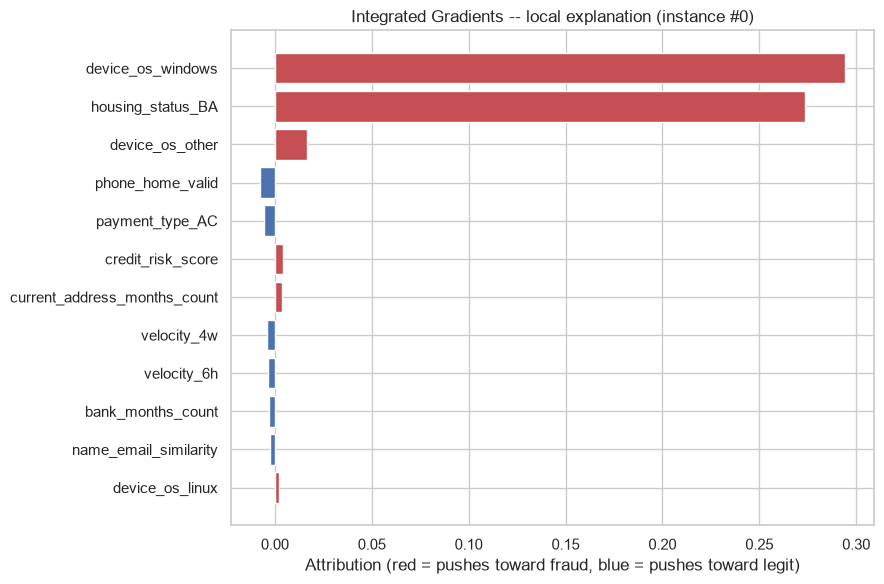

In [32]:
def plot_local_bar(attributions, feature_names, title, top_n=12, ax=None):
    """Simple horizontal bar chart of the top-N (by |value|) feature attributions for one
    instance -- a lightweight, method-agnostic stand-in for a waterfall/force plot, used
    for methods (LIME, Integrated Gradients) that don't ship SHAP-style plotting utilities.
    """
    s = pd.Series(attributions, index=feature_names)
    s = s.reindex(s.abs().sort_values(ascending=False).index).head(top_n).iloc[::-1]
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in s.values]
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(s.index, s.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel("Attribution (red = pushes toward fraud, blue = pushes toward legit)")
    return ax

plot_local_bar(ig_values[EXAMPLE_IDX], feature_names,
                f"Integrated Gradients -- local explanation (instance #{EXAMPLE_IDX})")
plt.tight_layout()
plt.show()


## 7. Comparing Post-hoc Methods Against TabNet's Native Explainability

**Goal:** bring all five explanation sources — TabNet-native, SHAP `KernelExplainer`,
SHAP `GradientExplainer`, LIME, and Integrated Gradients — into one place, at both the
global and local (per-instance) level, to see how much they agree.

### 7.1 Global ranking comparison

All five methods are reduced to a single "mean |importance|" ranking over the same
`feature_names`, and compared via **Spearman rank correlation** (rank-based, since the raw
scales of SHAP values / LIME weights / IG attributions / TabNet's attention scores are not
directly comparable in magnitude -- only in the *ordering* they induce over features).

**What to check (cells below):** in the heatmap, gradient-based methods (SHAP-Gradient,
Integrated Gradients) are expected to correlate most strongly with each other; KernelExplainer
and LIME, being purely perturbation-based, may agree less closely with them and with
TabNet-native -- that pattern is informative, not necessarily a problem. In the bar chart,
check which features TabNet-native ranks highest and whether the other methods echo that
ranking or diverge from it.


In [33]:
native_global_on_subset = pd.Series(
    np.abs(native_explain_matrix).mean(axis=0), index=feature_names
)

global_importance_df = pd.DataFrame({
    "TabNet_native": native_global_on_subset,
    "SHAP_Kernel": shap_kernel_global.reindex(feature_names),
    "SHAP_Gradient": shap_gradient_global.reindex(feature_names),
    "LIME": lime_global.reindex(feature_names),
    "Integrated_Gradients": ig_global.reindex(feature_names),
})

# Normalize each column to [0, 1] so magnitudes are visually comparable in the table/plots
# below (correlation itself is scale-invariant, this is purely for display)
global_importance_norm = global_importance_df / global_importance_df.max()

print("Top 10 features per method:")
top10_table = pd.DataFrame({
    col: global_importance_df[col].sort_values(ascending=False).head(10).index.tolist()
    for col in global_importance_df.columns
})
top10_table


Top 10 features per method:


,TabNet_native,SHAP_Kernel,SHAP_Gradient,LIME,Integrated_Gradients
0,device_os_windows,device_os_windows,device_os_windows,housing_status_BA,device_os_windows
1,housing_status_BE,housing_status_BA,housing_status_BA,device_os_windows,housing_status_BA
2,employment_status_CA,current_address_months_count,device_os_other,employment_status_CB,device_os_other
3,housing_status_BA,phone_home_valid,employment_status_CB,housing_status_BG,employment_status_CB
4,employment_status_CB,email_is_free,housing_status_BE,employment_status_CA,employment_status_CA
5,device_os_other,payment_type_AC,employment_status_CA,current_address_months_count,housing_status_BE
6,payment_type_AD,name_email_similarity,payment_type_AD,payment_type_AE,current_address_months_count
7,device_os_linux,keep_alive_session,current_address_months_count,housing_status_BE,email_is_free
8,current_address_months_count,velocity_4w,housing_status_BC,payment_type_AD,housing_status_BC
9,payment_type_AB,has_other_cards,email_is_free,payment_type_AC,device_os_linux


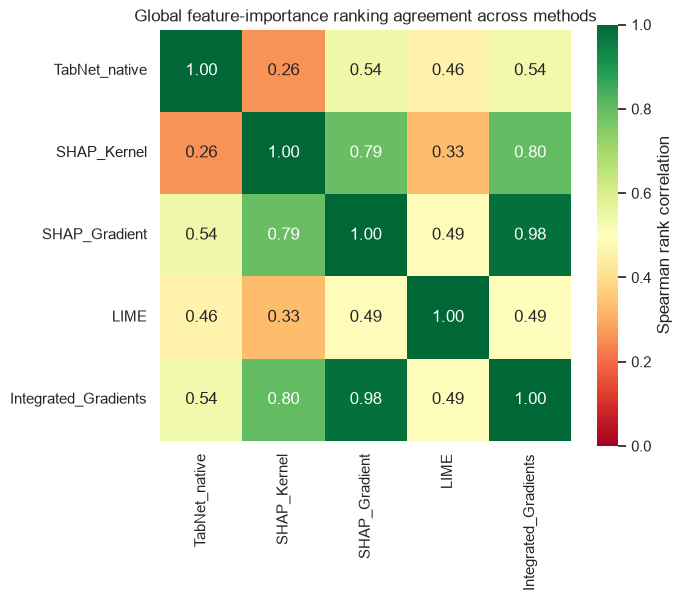

In [34]:
rank_corr_matrix = global_importance_df.corr(method="spearman")

plt.figure(figsize=(7, 6))
sns.heatmap(rank_corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Spearman rank correlation"})
plt.title("Global feature-importance ranking agreement across methods")
plt.tight_layout()
plt.show()

# Expected result: gradient-based methods (SHAP-Gradient, Integrated Gradients) should
# correlate most strongly with each other (same underlying gradient signal). KernelExplainer
# and LIME, being purely perturbation-based and black-box, may agree less closely with the
# gradient-based methods and with TabNet-native, which is informative in itself -- it shows
# how much the "story" about which features matter depends on the explanation mechanism used.


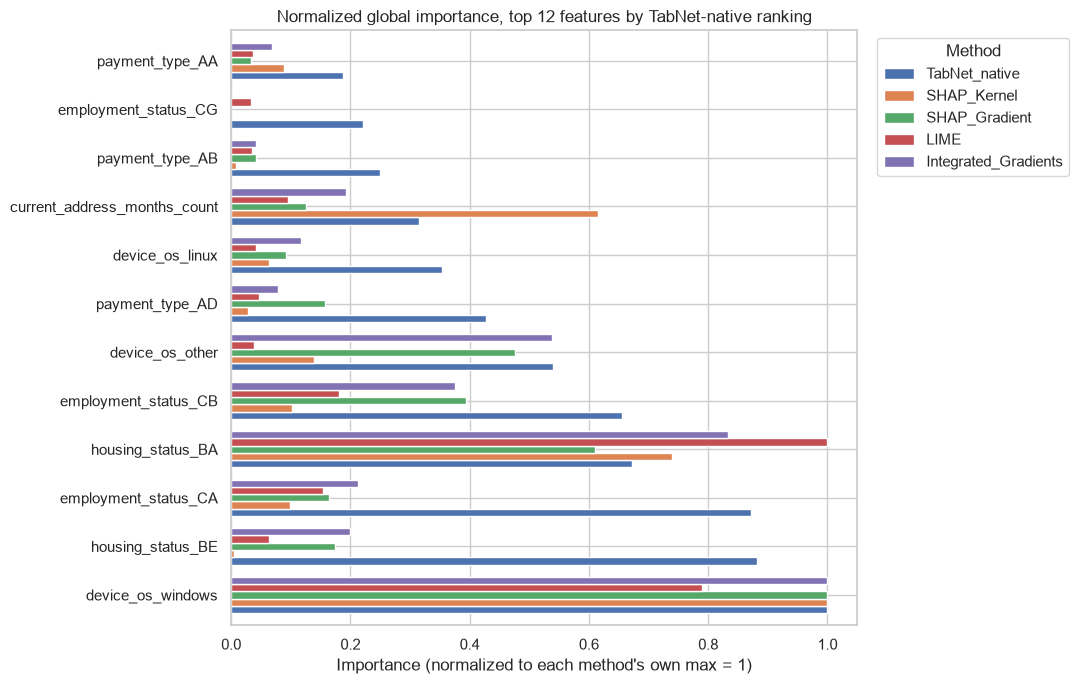

In [35]:
top_n = 12
fig, ax = plt.subplots(figsize=(11, 7))
global_importance_norm.loc[
    global_importance_df["TabNet_native"].sort_values(ascending=False).head(top_n).index
].plot(kind="barh", ax=ax, width=0.75)
ax.set_title(f"Normalized global importance, top {top_n} features by TabNet-native ranking")
ax.set_xlabel("Importance (normalized to each method's own max = 1)")
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 7.2 Feature importance aggregated by original variable

**Why this matters:** the top-ranked features in Section 7.1 for *every single method*
(including TabNet's own native ranking) are one-hot dummy columns from categorical
variables (`device_os_windows`, `housing_status_BA`, `employment_status_CA`...) -- almost
no numeric behavioral feature (`income`, `velocity_6h`, `credit_risk_score`...) appears in
any top-10 list. That's an unusual, striking pattern, and worth checking properly rather
than taking at face value, for two reasons:

1. **A methodological reason:** one-hot dummies are binary (mostly 0, occasionally 1),
   so per-column attribution methods can mechanically produce large point-attributions for
   them relative to continuous features, even before considering the model's actual
   reliance on them. Comparing individual dummy columns to individual numeric columns is
   not quite a fair, apples-to-apples comparison.
2. **A substantive reason, if the pattern survives a fairer comparison:** `employment_status`
   and `housing_status` are exactly the kind of variables the original BAF paper flags as
   protected-attribute-*adjacent* (alongside age/income) in its fairness discussion --
   if the model leans heavily on them, that's directly relevant to this TFM's GDPR Art. 22
   framing, not just a technical footnote.

To separate these two possibilities, we sum each one-hot dummy's attribution back to its
**parent categorical variable** (e.g. all `housing_status_*` columns -> `housing_status`),
so numeric and categorical features are compared as single units of equal "granularity".

**What to check:** compare the printed top-10-per-method table (aggregated) against the
un-aggregated table in the cells above. If the same categorical variables still dominate
after aggregating dummies back to their parent variable, treat that as a real, confirmed
pattern in the model's behavior rather than a one-hot-encoding artifact.


In [36]:
def get_parent_feature(feat_name, categorical_cols):
    """Map a one-hot dummy column back to its original categorical variable name;
    numeric features map to themselves.

    Sort categorical variable names by length to avoid prefix collisions if one categorical
    name starts with another.
    """
    for cat in sorted(categorical_cols, key=len, reverse=True):
        if feat_name.startswith(cat + "_"):
            return cat
    return feat_name

feature_parent_map = {f: get_parent_feature(f, categorical_features) for f in feature_names}

aggregated_importance = global_importance_df.copy()
aggregated_importance["__parent__"] = [feature_parent_map[f] for f in aggregated_importance.index]
aggregated_importance = aggregated_importance.groupby("__parent__").sum()

print("Top 10 ORIGINAL variables per method (one-hot dummies aggregated back together):")
top10_aggregated = pd.DataFrame({
    col: aggregated_importance[col].sort_values(ascending=False).head(10).index.tolist()
    for col in aggregated_importance.columns
})
top10_aggregated


Top 10 ORIGINAL variables per method (one-hot dummies aggregated back together):


,TabNet_native,SHAP_Kernel,SHAP_Gradient,LIME,Integrated_Gradients
0,device_os,device_os,device_os,housing_status,device_os
1,housing_status,housing_status,housing_status,device_os,housing_status
2,employment_status,current_address_months_count,employment_status,employment_status,employment_status
3,payment_type,payment_type,payment_type,payment_type,payment_type
4,current_address_months_count,phone_home_valid,current_address_months_count,current_address_months_count,current_address_months_count
5,device_distinct_emails_8w,email_is_free,email_is_free,source,email_is_free
6,has_other_cards,name_email_similarity,phone_home_valid,email_is_free,phone_home_valid
7,email_is_free,keep_alive_session,velocity_4w,velocity_4w,velocity_4w
8,proposed_credit_limit,employment_status,name_email_similarity,keep_alive_session,has_other_cards
9,source,velocity_4w,has_other_cards,session_length_in_minutes,name_email_similarity


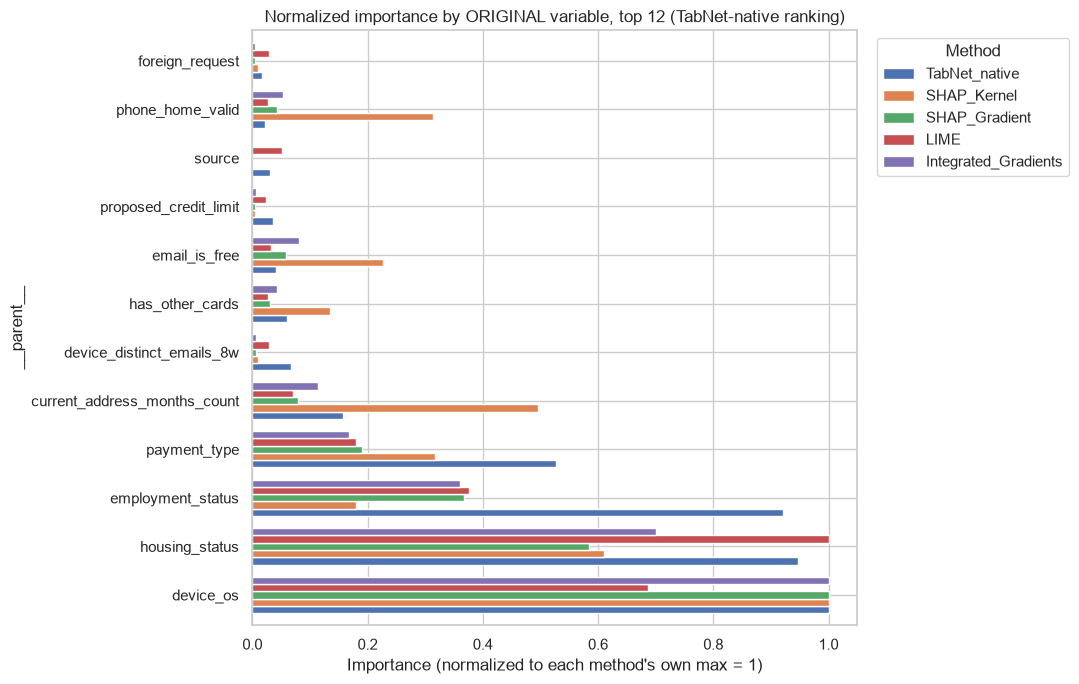

In [37]:
top_n_agg = 12
fig, ax = plt.subplots(figsize=(11, 7))
agg_norm = aggregated_importance / aggregated_importance.max()
agg_norm.loc[
    aggregated_importance["TabNet_native"].sort_values(ascending=False).head(top_n_agg).index
].plot(kind="barh", ax=ax, width=0.75)
ax.set_title(f"Normalized importance by ORIGINAL variable, top {top_n_agg} (TabNet-native ranking)")
ax.set_xlabel("Importance (normalized to each method's own max = 1)")
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Expected result / how to read this: if categorical variables (housing_status,
# employment_status, device_os) STILL dominate over numeric ones (income, velocity_6h,
# credit_risk_score) even after this fairer, variable-level aggregation, that is a genuine
# signal about the model's behavior -- not a one-hot-encoding artifact -- and should be
# flagged explicitly in the memoria's discussion of fairness/regulatory implications
# (these variables are adjacent to the protected attributes the BAF paper discusses).
# If numeric features climb substantially in this aggregated view, that instead confirms
# the flat, per-dummy comparison in Section 7.1 was partly a scale/granularity artifact.


In [38]:
# Extra sanity check for the categorical-dominance finding:
# group permutation importance by ORIGINAL variable, independent of any XAI attribution method.
# This checks whether variables that dominate explanations also affect model performance.

from collections import defaultdict

group_to_indices_for_perm = defaultdict(list)
for idx, f in enumerate(feature_names):
    group_to_indices_for_perm[feature_parent_map[f]].append(idx)

PERMUTATION_N = 10000 if not QUICK_MODE else 2000
rng_perm = np.random.RandomState(RANDOM_STATE)
perm_idx = rng_perm.choice(X_test_proc.shape[0], size=min(PERMUTATION_N, X_test_proc.shape[0]), replace=False)
X_perm_base = X_test_proc[perm_idx].astype(np.float32)
y_perm = y_test[perm_idx]

base_auc = roc_auc_score(y_perm, predict_proba_fn(X_perm_base))
perm_rows = []
for group, idxs in group_to_indices_for_perm.items():
    Xp = X_perm_base.copy()
    shuffled_rows = rng_perm.permutation(Xp.shape[0])
    # Shuffle all columns belonging to the original variable together. For one-hot categorical
    # blocks, this preserves valid category blocks from real rows.
    Xp[:, idxs] = Xp[shuffled_rows][:, idxs]
    auc_group = roc_auc_score(y_perm, predict_proba_fn(Xp))
    perm_rows.append({
        "original_variable": group,
        "auc_after_permutation": auc_group,
        "auc_drop": base_auc - auc_group,
        "n_model_columns": len(idxs),
    })

permutation_importance_original = pd.DataFrame(perm_rows).sort_values("auc_drop", ascending=False)
print(f"Baseline AUC on permutation sample: {base_auc:.4f}")
permutation_importance_original.head(15)

# Interpretation: if the same categorical variables dominate both XAI attributions and grouped
# permutation AUC drop, the categorical-dominance finding is more likely to be real model behavior.
# If not, treat the XAI dominance as a possible attribution artifact.


Baseline AUC on permutation sample: 0.8303


,original_variable,auc_after_permutation,auc_drop,n_model_columns
24,housing_status,0.779500,0.050769,7
26,device_os,0.785649,0.044621,5
2,current_address_months_count,0.800454,0.029815,1
23,employment_status,0.802687,0.027582,7
12,email_is_free,0.810177,0.020093,1
16,has_other_cards,0.815307,0.014963,1
13,phone_home_valid,0.817317,0.012952,1
22,payment_type,0.819140,0.011130,5
20,keep_alive_session,0.821312,0.008957,1
1,name_email_similarity,0.824281,0.005988,1


In [39]:
# Population-vs-balanced global comparison.
# This uses computationally cheaper methods to verify whether conclusions from the balanced
# diagnostic subset also appear under real test-set prevalence.

POP_GLOBAL_N = 500 if not QUICK_MODE else 200
X_pop_light = X_explain_pop[:min(POP_GLOBAL_N, X_explain_pop.shape[0])]

native_pop_matrix, _ = clf.explain(X_pop_light)
native_pop_global = pd.Series(np.abs(native_pop_matrix).mean(axis=0), index=feature_names).sort_values(ascending=False)

# Gradient SHAP on population subset.
t_pop = torch.tensor(X_pop_light.astype(np.float32), dtype=torch.float32)
vals_pop = np.array(gradient_explainer.shap_values(t_pop))
if vals_pop.ndim == 3:
    shap_gradient_pop = vals_pop[1] if vals_pop.shape[0] == 2 else vals_pop[..., 1]
else:
    shap_gradient_pop = vals_pop
shap_gradient_pop_global = pd.Series(np.abs(shap_gradient_pop).mean(axis=0), index=feature_names).sort_values(ascending=False)

# IG on a smaller population subset for runtime feasibility.
IG_POP_N = 200 if not QUICK_MODE else 80
ig_pop_values, _, _ = integrated_gradients_real_baselines(
    torch_model,
    X_explain_pop[:min(IG_POP_N, X_explain_pop.shape[0])],
    ig_baseline_refs[:min(5, ig_baseline_refs.shape[0])],
    target=1,
    n_steps=80 if not QUICK_MODE else 40,
)
ig_pop_global = pd.Series(np.abs(ig_pop_values).mean(axis=0), index=feature_names).sort_values(ascending=False)

population_global_top10 = pd.DataFrame({
    "Balanced_SHAP_Kernel_top10": shap_kernel_global.head(10).index,
    "Population_TabNet_native_top10": native_pop_global.head(10).index,
    "Population_SHAP_Gradient_top10": shap_gradient_pop_global.head(10).index,
    "Population_IG_top10": ig_pop_global.head(10).index,
})
display(population_global_top10)

print("Population subset fraud rate:", float(np.mean(y_explain_pop)))
print("Balanced subset fraud rate:", float(np.mean(y_explain)))
print("Use balanced subset for diagnostic/local fraud-vs-legit analysis; use population subset for deployment/global claims.")


,Balanced_SHAP_Kernel_top10,Population_TabNet_native_top10,Population_SHAP_Gradient_top10,Population_IG_top10
0,device_os_windows,employment_status_CA,device_os_windows,employment_status_CB
1,housing_status_BA,housing_status_BE,device_os_other,device_os_other
2,current_address_months_count,device_os_windows,housing_status_BA,device_os_windows
3,phone_home_valid,employment_status_CB,employment_status_CB,housing_status_BA
4,email_is_free,housing_status_BA,employment_status_CA,current_address_months_count
5,payment_type_AC,device_os_other,housing_status_BE,employment_status_CA
6,name_email_similarity,payment_type_AD,current_address_months_count,housing_status_BE
7,keep_alive_session,device_os_linux,payment_type_AD,has_other_cards
8,velocity_4w,housing_status_BB,device_os_linux,phone_home_valid
9,has_other_cards,current_address_months_count,email_is_free,payment_type_AD


Population subset fraud rate: 0.013
Balanced subset fraud rate: 0.5
Use balanced subset for diagnostic/local fraud-vs-legit analysis; use population subset for deployment/global claims.


### 7.3 Local (per-instance) comparison

For the same running example (`EXAMPLE_IDX`, used consistently in Sections 3-6), we place
all five local explanations side by side. This is the direct answer to "does the model's
explanation for *this specific solicitud de cuenta* depend on which XAI method you ask?"

**What to check:** in the 5-panel comparison, look for at least partial overlap in the top
2-3 bars across panels for this one instance, and note which panel(s) disagree most. The
heatmap in the next cell turns this visual impression into a number (Spearman rank
correlation of |attribution| across methods, for this instance only).


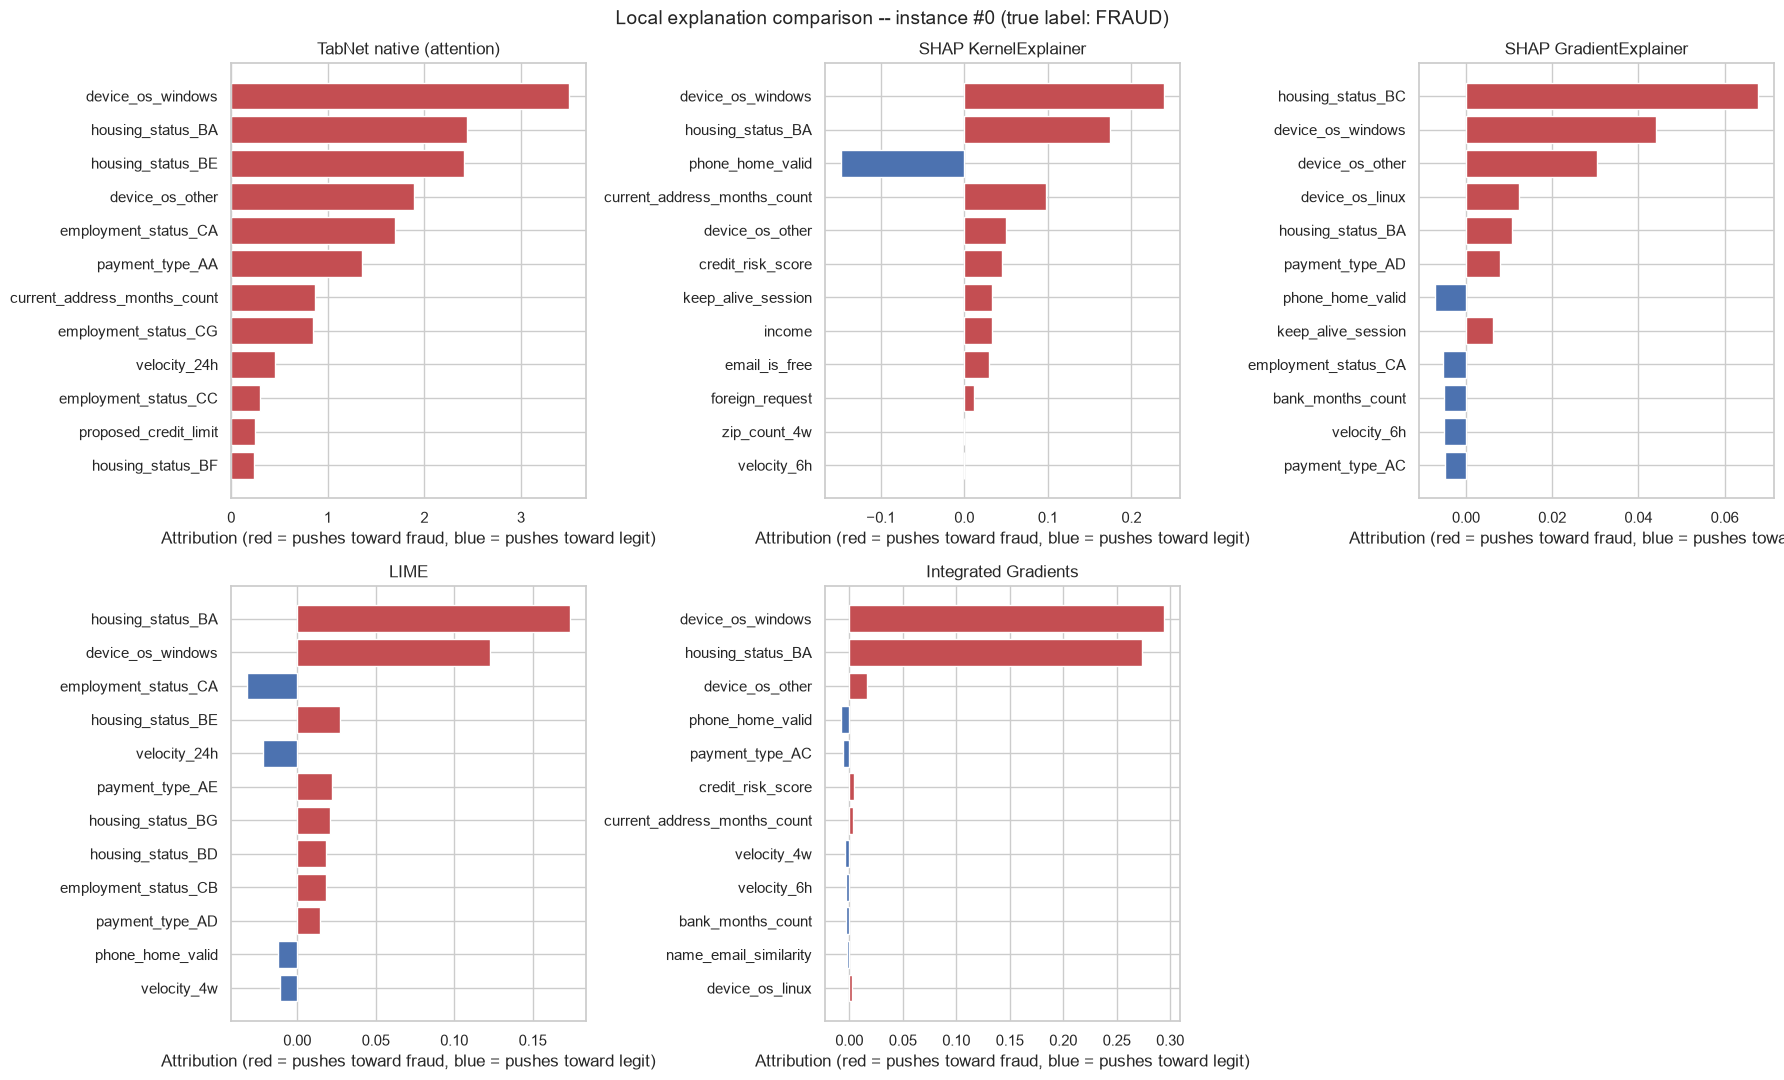

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

plot_local_bar(native_explain_matrix[EXAMPLE_IDX], feature_names,
                "TabNet native (attention)", ax=axes[0])
plot_local_bar(shap_values_kernel[EXAMPLE_IDX], feature_names,
                "SHAP KernelExplainer", ax=axes[1])
plot_local_bar(shap_values_gradient[EXAMPLE_IDX], feature_names,
                "SHAP GradientExplainer", ax=axes[2])
plot_local_bar(lime_values[EXAMPLE_IDX], feature_names,
                "LIME", ax=axes[3])
plot_local_bar(ig_values[EXAMPLE_IDX], feature_names,
                "Integrated Gradients", ax=axes[4])
axes[5].axis("off")

fig.suptitle(f"Local explanation comparison -- instance #{EXAMPLE_IDX} "
             f"(true label: {'FRAUD' if y_explain[EXAMPLE_IDX] == 1 else 'legit'})",
             fontsize=14)
plt.tight_layout()
plt.show()

# Expected result: some overlap in the top 2-3 features across most methods (the model's
# strongest local drivers should be hard to disagree on), but differences further down the
# ranking, and possibly some sign disagreements -- exactly the kind of nuance a qualitative
# comparison surfaces, which Section 8's quantitative metrics will help make more rigorous.


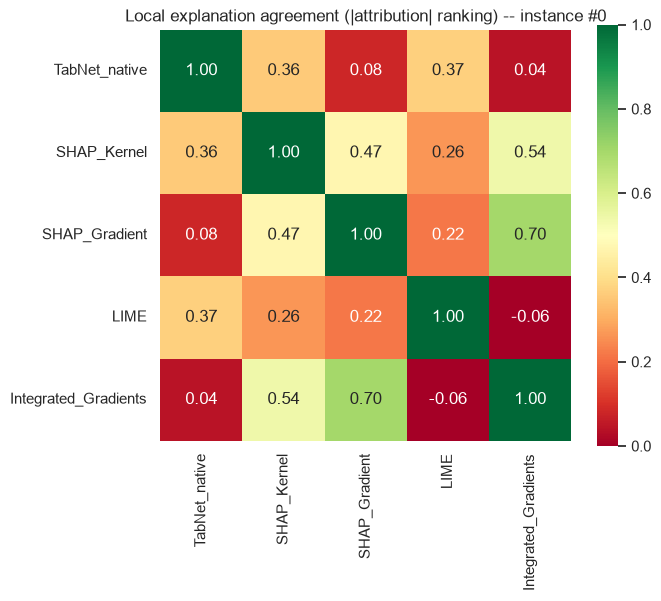

In [41]:
# Rank correlation between local explanations for this one instance, across methods
local_df = pd.DataFrame({
    "TabNet_native": native_explain_matrix[EXAMPLE_IDX],
    "SHAP_Kernel": shap_values_kernel[EXAMPLE_IDX],
    "SHAP_Gradient": shap_values_gradient[EXAMPLE_IDX],
    "LIME": lime_values[EXAMPLE_IDX],
    "Integrated_Gradients": ig_values[EXAMPLE_IDX],
}, index=feature_names)

local_rank_corr = local_df.abs().corr(method="spearman")

plt.figure(figsize=(7, 6))
sns.heatmap(local_rank_corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, square=True)
plt.title(f"Local explanation agreement (|attribution| ranking) -- instance #{EXAMPLE_IDX}")
plt.tight_layout()
plt.show()


## 8. Quantitative Evaluation of Explanation Quality

**Goal:** move beyond visual/qualitative comparison and measure, numerically, how good
each method's explanations actually are, along three axes:

- **Fidelity** (a.k.a. faithfulness): do the features an explanation flags as important
  *actually* drive the model's prediction when perturbed? Measured via **Faithfulness
  Correlation** — correlating the sum of attributions for a randomly masked feature subset
  with the resulting drop in predicted probability.
- **Robustness**: does the explanation stay (roughly) the same for (almost) the same
  input? Measured via **Max-Sensitivity** — the largest change in the explanation induced
  by a small random perturbation of the input, normalized by the perturbation's size
  (lower = more robust).
- **Stability**: are similar inputs given similar explanations? Measured as the average
  **cosine similarity** between the explanations of each instance and its nearest neighbor
  in feature space (higher = more consistent).

**On Quantus/OpenXAI:** we attempt to cross-check the fidelity/robustness results against
`quantus`'s own implementations where the installed version's API allows it (Section 8.4).
However, `quantus`'s function signatures have changed across versions, and a broken import
or signature mismatch would otherwise stop the whole notebook -- so the **primary,
guaranteed-to-run results** come from the manual implementations below (Sections 8.1-8.3),
which follow the same definitions used in the XAI evaluation literature (Bhatt et al. 2020
for faithfulness correlation; Yeh et al. 2019 for max-sensitivity) and in `quantus` itself.


### 8.1 Fidelity (Faithfulness Correlation)

For each instance: repeatedly mask a random subset of features (replace with 0, the
standardized "neutral" value), and check whether the *sum of that subset's attributions*
correlates with the *actual drop in P(fraud)* caused by masking them. A method whose
attributions are faithful to the model's real behavior should show a strong positive
correlation.

**What to check:** this cell can take a while (`FIDELITY_N_INSTANCES` x `FIDELITY_NR_RUNS`
perturbations per method). The printed per-method means are the *naive* fidelity numbers --
Section 8.1b below corrects them; don't use these naive numbers in the final comparison
(Section 9) without reading 8.1b first.


In [42]:
def _sample_reference_row(baseline_pool, rng):
    """Sample one valid reference row from a real-row baseline pool."""
    return baseline_pool[rng.randint(0, baseline_pool.shape[0])]


def faithfulness_correlation(X, attributions, predict_fn, nr_runs=15, subset_size=None,
                              baseline_pool=None, random_state=RANDOM_STATE):
    """Per-instance Pearson correlation between summed attributions for a masked feature
    subset and the prediction drop caused by replacing that subset with values from REAL
    reference rows.

    The naive per-dummy version may still create invalid one-hot states when only part of a
    categorical block is perturbed. It is kept as a diagnostic. The grouped version below is
    the preferred one for cross-method reporting.
    """
    rng = np.random.RandomState(random_state)
    n_samples, n_features = X.shape
    if subset_size is None:
        subset_size = max(1, n_features // 4)
    subset_size = min(subset_size, n_features - 1)
    baseline_pool = xai_baseline_pool if baseline_pool is None else baseline_pool.astype(np.float32)

    base_preds = predict_fn(X)
    scores = np.full(n_samples, np.nan)

    for i in range(n_samples):
        sum_attrs, drops = [], []
        for _ in range(nr_runs):
            feat_subset = rng.choice(n_features, size=subset_size, replace=False)
            ref = _sample_reference_row(baseline_pool, rng)
            x_perturbed = X[i].copy()
            x_perturbed[feat_subset] = ref[feat_subset]
            pred_perturbed = predict_fn(x_perturbed[None, :])[0]
            drops.append(base_preds[i] - pred_perturbed)
            sum_attrs.append(attributions[i, feat_subset].sum())
        if np.std(sum_attrs) > 1e-8 and np.std(drops) > 1e-8:
            scores[i], _ = pearsonr(sum_attrs, drops)
    return scores


In [43]:
fidelity_X = X_explain[:FIDELITY_N_INSTANCES]

fidelity_results = {}
attribution_slices = {
    "TabNet_native": native_explain_matrix[:FIDELITY_N_INSTANCES],
    "SHAP_Kernel": shap_values_kernel[:min(FIDELITY_N_INSTANCES, N_KERNEL_LIME_INSTANCES)],
    "SHAP_Gradient": shap_values_gradient[:FIDELITY_N_INSTANCES],
    "LIME": lime_values[:min(FIDELITY_N_INSTANCES, N_KERNEL_LIME_INSTANCES)],
    "Integrated_Gradients": ig_values[:FIDELITY_N_INSTANCES],
}

for method, attribs in attribution_slices.items():
    n = attribs.shape[0]
    scores = faithfulness_correlation(
        fidelity_X[:n], attribs, predict_proba_fn,
        nr_runs=FIDELITY_NR_RUNS,
        baseline_pool=xai_baseline_pool,
    )
    fidelity_results[method] = scores
    print(f"{method:22s} naive fidelity (mean Pearson r): {np.nanmean(scores):.4f}  (n={n})")


TabNet_native          naive fidelity (mean Pearson r): 0.0825  (n=50)
SHAP_Kernel            naive fidelity (mean Pearson r): 0.5098  (n=50)
SHAP_Gradient          naive fidelity (mean Pearson r): 0.2021  (n=50)
LIME                   naive fidelity (mean Pearson r): 0.1022  (n=50)
Integrated_Gradients   naive fidelity (mean Pearson r): 0.3513  (n=50)


### 8.1b One-hot-aware fidelity (methodological check)

**Why this cell exists:** `SHAP_Kernel` and `SHAP_Gradient` came back with *negative*
fidelity above -- masking their top-attributed features correlates with predictions moving
the "wrong" way. Before concluding those methods are unfaithful, there's a plausible
alternative explanation to rule out: the fidelity test masks **individual one-hot dummy
columns independently**. Zeroing out just `device_os_windows` while leaving
`device_os_linux`, `device_os_other`, etc. at their real (mostly-zero) values can produce
an input where *every* `device_os_*` dummy reads 0 -- an "impossible" application with no
operating system at all, a state the model never saw during training. Its behavior on such
an out-of-distribution input is undefined, which can corrupt the fidelity measurement
independently of whether the explanation is actually faithful.

The fix: perturb at the level of **original variables**, not processed columns -- when a
categorical variable is selected for masking, zero out *all* of its one-hot dummies
together (a valid "unknown category" state), instead of one dummy at a time.

**What to check:** compare the printed "Naive (per-dummy)" vs "One-hot-aware (per-variable)"
columns per method. If `SHAP_Kernel` / `SHAP_Gradient`'s scores improve substantially under
the one-hot-aware version, that confirms the negative naive scores were largely a
perturbation-validity artifact. The one-hot-aware column (`fidelity_results_grouped`) is
what Section 9 uses downstream.


In [44]:
from collections import defaultdict

parent_to_indices = defaultdict(list)
for idx, f in enumerate(feature_names):
    parent_to_indices[feature_parent_map[f]].append(idx)
original_variables = list(parent_to_indices.keys())
print(f"{len(original_variables)} original variables underlie the {N_FEATURES} model-input columns "
      f"({len(feature_names) - len(original_variables)} of them collapse from multi-dummy categoricals).")


def faithfulness_correlation_grouped(X, attributions, predict_fn, parent_to_indices,
                                      nr_runs=15, subset_size_vars=None,
                                      baseline_pool=None, random_state=RANDOM_STATE):
    """Preferred faithfulness metric for one-hot data.

    Perturbs whole ORIGINAL variables at a time. For categorical variables, all dummy columns
    are copied from the same real reference row, preserving valid one-hot category blocks.
    """
    rng = np.random.RandomState(random_state)
    n_samples = X.shape[0]
    variables = list(parent_to_indices.keys())
    if subset_size_vars is None:
        subset_size_vars = max(1, len(variables) // 4)
    subset_size_vars = min(subset_size_vars, len(variables) - 1)
    baseline_pool = xai_baseline_pool if baseline_pool is None else baseline_pool.astype(np.float32)

    base_preds = predict_fn(X)
    scores = np.full(n_samples, np.nan)

    for i in range(n_samples):
        sum_attrs, drops = [], []
        for _ in range(nr_runs):
            chosen_vars = rng.choice(variables, size=subset_size_vars, replace=False)
            chosen_idx = [idx for v in chosen_vars for idx in parent_to_indices[v]]
            ref = _sample_reference_row(baseline_pool, rng)
            x_perturbed = X[i].copy()
            x_perturbed[chosen_idx] = ref[chosen_idx]
            pred_perturbed = predict_fn(x_perturbed[None, :])[0]
            drops.append(base_preds[i] - pred_perturbed)
            sum_attrs.append(attributions[i, chosen_idx].sum())
        if np.std(sum_attrs) > 1e-8 and np.std(drops) > 1e-8:
            scores[i], _ = pearsonr(sum_attrs, drops)
    return scores


fidelity_results_grouped = {}
for method, attribs in attribution_slices.items():
    n = attribs.shape[0]
    scores = faithfulness_correlation_grouped(
        fidelity_X[:n], attribs, predict_proba_fn, parent_to_indices,
        nr_runs=FIDELITY_NR_RUNS,
        baseline_pool=xai_baseline_pool,
    )
    fidelity_results_grouped[method] = scores
    print(f"{method:22s} one-hot-aware fidelity (mean Pearson r): {np.nanmean(scores):.4f}  (n={n})")

print()
print("Comparison -- naive (per-dummy) vs. one-hot-aware (per-original-variable) fidelity:")
comparison_fidelity = pd.DataFrame({
    "Naive (per-dummy)": {m: np.nanmean(v) for m, v in fidelity_results.items()},
    "One-hot-aware (per-variable)": {m: np.nanmean(v) for m, v in fidelity_results_grouped.items()},
})
comparison_fidelity


27 original variables underlie the 48 model-input columns (21 of them collapse from multi-dummy categoricals).
TabNet_native          one-hot-aware fidelity (mean Pearson r): 0.0369  (n=50)
SHAP_Kernel            one-hot-aware fidelity (mean Pearson r): 0.5392  (n=50)
SHAP_Gradient          one-hot-aware fidelity (mean Pearson r): 0.2888  (n=50)
LIME                   one-hot-aware fidelity (mean Pearson r): 0.1557  (n=50)
Integrated_Gradients   one-hot-aware fidelity (mean Pearson r): 0.3955  (n=50)

Comparison -- naive (per-dummy) vs. one-hot-aware (per-original-variable) fidelity:


,Naive (per-dummy),One-hot-aware (per-variable)
TabNet_native,0.082523,0.036863
SHAP_Kernel,0.509841,0.539173
SHAP_Gradient,0.202094,0.288771
LIME,0.102181,0.155675
Integrated_Gradients,0.351308,0.395496


In [45]:
# Logit-target fidelity.
# Because calibration diagnostics show that the original softmax probability is not well calibrated,
# compute an additional faithfulness test in raw fraud-logit space. This avoids interpreting
# fidelity only through a saturated/over-confident probability scale.

fidelity_results_grouped_logit = {}

# Only include attribution methods that were explicitly computed for a logit target.
# Probability-target SHAP/LIME attributions are not mixed with logit drops here.
attribution_slices_logit = {
    "SHAP_Kernel_Logit": shap_values_kernel_logit[:min(FIDELITY_N_INSTANCES, shap_values_kernel_logit.shape[0])],
    "Integrated_Gradients_Logit": ig_values_logit[:FIDELITY_N_INSTANCES],
}

for method, attribs in attribution_slices_logit.items():
    n = min(attribs.shape[0], FIDELITY_N_INSTANCES)
    scores = faithfulness_correlation_grouped(
        fidelity_X[:n],
        attribs[:n],
        predict_logit_fn,
        parent_to_indices,
        nr_runs=FIDELITY_NR_RUNS,
        baseline_pool=xai_baseline_pool,
    )
    fidelity_results_grouped_logit[method] = scores
    print(f"{method:28s} logit-target one-hot-aware fidelity (mean Pearson r): {np.nanmean(scores):.4f}  (n={n})")

logit_fidelity_summary = pd.DataFrame({
    "Logit fidelity mean": {m: np.nanmean(v) for m, v in fidelity_results_grouped_logit.items()},
    "N": {m: np.sum(~np.isnan(v)) for m, v in fidelity_results_grouped_logit.items()},
}).round(4)
logit_fidelity_summary


SHAP_Kernel_Logit            logit-target one-hot-aware fidelity (mean Pearson r): 0.5565  (n=50)
Integrated_Gradients_Logit   logit-target one-hot-aware fidelity (mean Pearson r): 0.4514  (n=50)


,Logit fidelity mean,N
SHAP_Kernel_Logit,0.5565,50
Integrated_Gradients_Logit,0.4514,50


### 8.2 Robustness (Max-Sensitivity)

For each instance, apply several small random (Gaussian) perturbations to the input,
recompute the explanation each time, and measure the largest resulting change in the
explanation, normalized by the perturbation's magnitude. **Lower is more robust** — the
explanation shouldn't swing wildly for a nearly-identical input.

Recomputing explanations is cheap for the gradient-based/native methods, but expensive for
`KernelExplainer`/LIME, so we use smaller instance/repeat budgets for those (see
`ROBUSTNESS_N_INSTANCES_SLOW` in Section 0.1).

**What to check:** one line prints per method. The fast methods (TabNet-native,
SHAP-Gradient, IG) should print quickly; the slow ones (SHAP-Kernel, LIME) may take
noticeably longer given `ROBUSTNESS_N_INSTANCES_SLOW`. These are the *raw* sensitivity
numbers -- Section 8.2b below corrects them for cross-method comparison.


In [46]:
def max_sensitivity(X, attribution_fn, n_instances, n_repeats, epsilon=0.05, random_state=RANDOM_STATE):
    """attribution_fn: numpy array (n, n_features) -> attributions (n, n_features)."""
    rng = np.random.RandomState(random_state)
    idxs = rng.choice(X.shape[0], size=min(n_instances, X.shape[0]), replace=False)
    sensitivities = []
    for i in idxs:
        x = X[i:i + 1]
        a_orig = attribution_fn(x)[0]
        max_change = 0.0
        for _ in range(n_repeats):
            noise = rng.normal(scale=epsilon, size=x.shape)
            a_pert = attribution_fn(x + noise)[0]
            change = np.linalg.norm(a_pert - a_orig) / (np.linalg.norm(noise) + 1e-8)
            max_change = max(max_change, change)
        sensitivities.append(max_change)
    return np.array(sensitivities)


def tabnet_native_attrib_fn(X):
    explain_matrix, _ = clf.explain(X)
    return explain_matrix

def shap_gradient_attrib_fn(X):
    t = torch.tensor(X, dtype=torch.float32)
    vals = np.array(gradient_explainer.shap_values(t))
    if vals.ndim == 3:
        vals = vals[1] if vals.shape[0] == 2 else vals[..., 1]
    return vals

def ig_attrib_fn(X):
    # Use a reduced set of real baselines for robustness calculations to keep runtime feasible.
    baseline_refs = ig_baseline_refs[:min(5, ig_baseline_refs.shape[0])]
    attrs = []
    for b in baseline_refs:
        t = torch.tensor(X.astype(np.float32), dtype=torch.float32, requires_grad=True)
        baseline_np = np.repeat(b.reshape(1, -1), X.shape[0], axis=0)
        baseline_t = torch.tensor(baseline_np, dtype=torch.float32)
        attr = integrated_gradients.attribute(t, baselines=baseline_t, target=1, n_steps=50)
        attrs.append(attr.detach().numpy())
    return np.mean(attrs, axis=0)

def shap_kernel_attrib_fn(X):
    vals = kernel_explainer.shap_values(X, nsamples=KERNEL_NSAMPLES)
    vals = np.array(vals)
    if vals.ndim == 3:
        vals = vals[0]
    return vals

def lime_attrib_fn(X):
    out = np.zeros((X.shape[0], N_FEATURES))
    for i in range(X.shape[0]):
        exp = lime_explainer.explain_instance(
            X[i], predict_fn=lambda x: clf.predict_proba(x),
            num_features=N_FEATURES, num_samples=LIME_NUM_SAMPLES,
        )
        for feat_idx, weight in exp.as_map()[1]:
            out[i, feat_idx] = weight
    return out


In [47]:
robustness_results = {}

fast_methods = {
    "TabNet_native": tabnet_native_attrib_fn,
    "SHAP_Gradient": shap_gradient_attrib_fn,
    "Integrated_Gradients": ig_attrib_fn,
}
slow_methods = {
    "SHAP_Kernel": shap_kernel_attrib_fn,
    "LIME": lime_attrib_fn,
}

for method, fn in fast_methods.items():
    scores = max_sensitivity(X_explain, fn, ROBUSTNESS_N_INSTANCES_FAST, ROBUSTNESS_N_REPEATS)
    robustness_results[method] = scores
    print(f"{method:22s} robustness (mean max-sensitivity, lower=better): {scores.mean():.4f}")

for method, fn in slow_methods.items():
    scores = max_sensitivity(X_explain[:N_KERNEL_LIME_INSTANCES], fn,
                              ROBUSTNESS_N_INSTANCES_SLOW, ROBUSTNESS_N_REPEATS)
    robustness_results[method] = scores
    print(f"{method:22s} robustness (mean max-sensitivity, lower=better): {scores.mean():.4f}")


TabNet_native          robustness (mean max-sensitivity, lower=better): 77.3771
SHAP_Gradient          robustness (mean max-sensitivity, lower=better): 3.8787
Integrated_Gradients   robustness (mean max-sensitivity, lower=better): 2.5380


100%|██████████| 1/1 [00:00<00:00,  2.20it/s]


SHAP_Kernel            robustness (mean max-sensitivity, lower=better): 2.0161
LIME                   robustness (mean max-sensitivity, lower=better): 0.2933


### 8.2b Normalized robustness (methodological check)

**Why this cell exists:** `TabNet_native` came back with a mean max-sensitivity of
**~77**, roughly 15-300x higher (i.e. apparently far less robust) than every other method
(which range ~0.26-4.3). That gap is too large to take at face value without checking the
metric itself first.

Max-Sensitivity, as defined above, is `||explanation(x+delta) - explanation(x)|| / ||delta||`
-- it is **not normalized by the explanation's own scale**. TabNet's native
`explain_matrix` is an aggregated attention score across `n_steps` decision steps (values
can exceed 1), while SHAP/LIME/IG attributions live in probability space (typically much
smaller in magnitude). A method whose attributions are simply *larger numbers* will show
a larger absolute sensitivity even if it is proportionally just as stable -- so the raw
comparison above is not quite apples-to-apples across methods with different attribution
scales.

The fix: also report a **relative** version, normalized by the explanation's own norm, so
all five methods are compared on the same (unitless) footing.

**What to check:** compare "Raw max-sensitivity" vs "Relative max-sensitivity" per method. If
`TabNet_native`'s relative ranking looks far more comparable to the other methods than its
raw ranking did, that confirms the raw gap was mostly a scale artifact rather than a genuine
15-300x robustness difference. `robustness_results_relative` is what Section 9 uses
downstream.


In [48]:
def relative_max_sensitivity(X, attribution_fn, n_instances, n_repeats, epsilon=0.05, random_state=RANDOM_STATE):
    """Same perturbation procedure as max_sensitivity, but normalizes the change in
    explanation by the explanation's own norm -- a scale-invariant version, comparable
    across methods whose attributions live on very different numeric scales."""
    rng = np.random.RandomState(random_state)
    idxs = rng.choice(X.shape[0], size=min(n_instances, X.shape[0]), replace=False)
    sensitivities = []
    for i in idxs:
        x = X[i:i + 1]
        a_orig = attribution_fn(x)[0]
        a_orig_norm = np.linalg.norm(a_orig) + 1e-8
        max_change = 0.0
        for _ in range(n_repeats):
            noise = rng.normal(scale=epsilon, size=x.shape)
            a_pert = attribution_fn(x + noise)[0]
            change = (np.linalg.norm(a_pert - a_orig) / a_orig_norm) / (np.linalg.norm(noise) + 1e-8)
            max_change = max(max_change, change)
        sensitivities.append(max_change)
    return np.array(sensitivities)


robustness_results_relative = {}

for method, fn in fast_methods.items():
    scores = relative_max_sensitivity(X_explain, fn, ROBUSTNESS_N_INSTANCES_FAST, ROBUSTNESS_N_REPEATS)
    robustness_results_relative[method] = scores
    print(f"{method:22s} relative robustness (lower=better): {scores.mean():.4f}")

for method, fn in slow_methods.items():
    scores = relative_max_sensitivity(X_explain[:N_KERNEL_LIME_INSTANCES], fn,
                                       ROBUSTNESS_N_INSTANCES_SLOW, ROBUSTNESS_N_REPEATS)
    robustness_results_relative[method] = scores
    print(f"{method:22s} relative robustness (lower=better): {scores.mean():.4f}")

print()
print("Comparison -- raw (scale-sensitive) vs. relative (scale-normalized) robustness:")
comparison_robustness = pd.DataFrame({
    "Raw max-sensitivity": {m: v.mean() for m, v in robustness_results.items()},
    "Relative max-sensitivity": {m: v.mean() for m, v in robustness_results_relative.items()},
})
comparison_robustness

# Expected result: TabNet_native's relative ranking should look much more reasonable here.
# Use robustness_results_relative (not the raw one) as the number you cite for cross-method
# robustness comparison in the memoria; keep the raw one only as a within-method sanity
# check (e.g. tracking whether one method's own robustness improves after a hyperparameter
# change), since it's not meaningful across methods with different attribution scales.


TabNet_native          relative robustness (lower=better): 9.8099
SHAP_Gradient          relative robustness (lower=better): 13.8089
Integrated_Gradients   relative robustness (lower=better): 10.5846


100%|██████████| 1/1 [00:00<00:00,  2.48it/s]


SHAP_Kernel            relative robustness (lower=better): 12.9982
LIME                   relative robustness (lower=better): 1.1472

Comparison -- raw (scale-sensitive) vs. relative (scale-normalized) robustness:


,Raw max-sensitivity,Relative max-sensitivity
TabNet_native,77.377108,9.809862
SHAP_Gradient,3.878686,13.808945
Integrated_Gradients,2.537996,10.584639
SHAP_Kernel,2.016137,12.998226
LIME,0.293266,1.147213


### 8.3 Stability (consistency between similar samples)

For each instance in a method's explained subset, find its nearest neighbor (Euclidean
distance in the model's input feature space) and measure the **cosine similarity** between
their two explanation vectors. A stable explainer should give similar explanations to
similar applications -- **higher is more stable**.

This reuses the attribution matrices already computed in Sections 3-6 (no need to
recompute anything), restricted to whichever subset size each method was run on.

**What to check:** this should run quickly, since it only reuses attribution matrices already
computed in Sections 3-6 (no recomputation). If LIME's stability score comes out notably
higher than the other methods', check whether that lines up with a *lower* fidelity score for
LIME -- Section 9.1 discusses this exact fidelity/stability trade-off.


In [49]:
def stability_score(X, attributions, k=1):
    """Average cosine similarity between each instance's explanation and its k nearest
    neighbors' explanations (neighbors found in X's feature space)."""
    dist = euclidean_distances(X)
    np.fill_diagonal(dist, np.inf)
    scores = []
    for i in range(X.shape[0]):
        nn_idx = np.argsort(dist[i])[:k]
        for j in nn_idx:
            sim = cosine_similarity(attributions[i:i + 1], attributions[j:j + 1])[0, 0]
            scores.append(sim)
    return np.array(scores)


stability_results = {}
stability_inputs = {
    "TabNet_native": (X_explain, native_explain_matrix),
    "SHAP_Kernel": (X_explain[:N_KERNEL_LIME_INSTANCES], shap_values_kernel),
    "SHAP_Gradient": (X_explain, shap_values_gradient),
    "LIME": (X_explain[:N_KERNEL_LIME_INSTANCES], lime_values),
    "Integrated_Gradients": (X_explain, ig_values),
}

for method, (X_m, attribs) in stability_inputs.items():
    scores = stability_score(X_m, attribs, k=1)
    stability_results[method] = scores
    print(f"{method:22s} stability (mean cosine similarity, higher=better): {np.nanmean(scores):.4f}")


TabNet_native          stability (mean cosine similarity, higher=better): 0.6596
SHAP_Kernel            stability (mean cosine similarity, higher=better): 0.3414
SHAP_Gradient          stability (mean cosine similarity, higher=better): 0.1662
LIME                   stability (mean cosine similarity, higher=better): 0.9480
Integrated_Gradients   stability (mean cosine similarity, higher=better): 0.2631


In [50]:
# Strong recommended check: LIME repeated-seed stability.
# The previous stability metric compares explanations of neighboring instances. This cell checks
# whether LIME's explanation for the SAME instances changes when LIME's random seed changes.

LIME_SEED_CHECK_INSTANCES = 20 if not QUICK_MODE else 8
LIME_SEEDS = [0, 1, 2, 3, 4]
TOP_K_LIME = 10


def lime_values_for_seed(seed, X_subset):
    explainer = LimeTabularExplainer(
        training_data=X_train_proc,
        feature_names=feature_names,
        class_names=["legit", "fraud"],
        mode="classification",
        discretize_continuous=False,
        random_state=seed,
    )
    vals = np.zeros((X_subset.shape[0], N_FEATURES))
    for i in range(X_subset.shape[0]):
        exp = explainer.explain_instance(
            X_subset[i],
            predict_fn=lambda x: clf.predict_proba(x),
            num_features=N_FEATURES,
            num_samples=LIME_NUM_SAMPLES,
        )
        for feat_idx, weight in exp.as_map()[1]:
            vals[i, feat_idx] = weight
    return vals


X_lime_seed = X_explain[:LIME_SEED_CHECK_INSTANCES]
lime_seed_values = {seed: lime_values_for_seed(seed, X_lime_seed) for seed in LIME_SEEDS}

seed_pairs = list(combinations(LIME_SEEDS, 2))
overlaps = []
cosines = []
for s1, s2 in seed_pairs:
    v1, v2 = lime_seed_values[s1], lime_seed_values[s2]
    for i in range(X_lime_seed.shape[0]):
        top1 = set(np.argsort(np.abs(v1[i]))[::-1][:TOP_K_LIME])
        top2 = set(np.argsort(np.abs(v2[i]))[::-1][:TOP_K_LIME])
        overlaps.append(len(top1 & top2) / TOP_K_LIME)
        cosines.append(cosine_similarity(v1[i:i+1], v2[i:i+1])[0, 0])

print(f"LIME repeated-seed top-{TOP_K_LIME} overlap mean:", round(float(np.mean(overlaps)), 4))
print("LIME repeated-seed cosine similarity mean:", round(float(np.mean(cosines)), 4))
print("If these are low, LIME stability in the summary table should be interpreted cautiously.")


LIME repeated-seed top-10 overlap mean: 0.606
LIME repeated-seed cosine similarity mean: 0.9497
If these are low, LIME stability in the summary table should be interpreted cautiously.


### 8.4 Optional cross-check with `quantus`

Two blind attempts to match this installed `quantus` version's `FaithfulnessCorrelation`
signature both failed with different, somewhat contradictory errors (`subset_size=12`:
"must be smaller than input size [12 >= 1.0]"; `subset_size=0.25`: "expected a sequence of
integers or a single integer"). Rather than guess a third time, this cell now **introspects
the installed API directly** (version + signature) and prints it, then attempts the call
wrapped in `try/except` as before. If it still fails, the printed signature/docstring is
what you need to fix the call by hand -- and either way, the manual metrics in Sections
8.1-8.3 remain this notebook's primary, citable results (which is the whole reason they
were built to not depend on `quantus` in the first place).

**What to check:** if this cell errors, that is an accepted, expected outcome for this
optional cross-check -- nothing in Section 9's primary results depends on it succeeding. If
you want to pursue a working Quantus integration further, the printed version and function
signature above are the starting point.


In [51]:
# Quantus optional cross-check.
# In this TabNet/tabular setup, Quantus 0.6.0 interprets the input dimensionality in a way that
# can produce misleading shape/subset_size errors for flat tabular arrays. To avoid presenting
# an unfinished or unreliable result, the final thesis results use the manual, self-contained
# metrics above (one-hot-aware fidelity, relative robustness, and nearest-neighbor stability).

RUN_QUANTUS_OPTIONAL = False

if RUN_QUANTUS_OPTIONAL and QUANTUS_AVAILABLE:
    print("Quantus optional experiment enabled. If it fails, do not use it in final conclusions.")
    # Keep this as a sandbox only. The manual metrics above are the official benchmark.
else:
    print("Quantus cross-check intentionally skipped in final notebook.")
    print("Reason: manual metrics are transparent, one-hot-aware, and reproducible for flat tabular data.")


Quantus cross-check intentionally skipped in final notebook.
Reason: manual metrics are transparent, one-hot-aware, and reproducible for flat tabular data.


## 9. Comparative Summary: Fidelity, Robustness & Stability Across Methods

**Goal:** consolidate Section 8's results into a single table and chart, so the five
explanation methods can be ranked and compared at a glance -- this is the evidence base
for the memoria's recommendation on which XAI method(s) are best suited to this banking
fraud use case.

**Note on directionality:** fidelity and stability are "higher = better"; robustness
(max-sensitivity) is "lower = better" -- kept in its original units in the table, but
inverted (`1 / (1 + sensitivity)`) in the normalized comparison chart so that "higher bar"
consistently means "better" across all three panels.

**What to check (cells below):** confirm `summary_table` is built from
`fidelity_results_grouped` and `robustness_results_relative` -- the corrected metrics, not
the naive/raw ones -- by comparing its printed numbers against what Sections 8.1b/8.2b
printed. In the normalized bar chart and radar chart, remember that all three axes have been
rescaled so "higher = better" everywhere, even though Robustness's underlying raw metric is
"lower = better".


In [52]:
# Bootstrap confidence intervals for final metrics.
# Point estimates alone can overstate certainty. The CIs below quantify sampling variability
# over the evaluated instances/repeats for fidelity, relative robustness, and stability.

def bootstrap_ci(scores, n_boot=1000, alpha=0.05, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    scores = np.asarray(scores, dtype=float)
    scores = scores[~np.isnan(scores)]
    if len(scores) == 0:
        return np.nan, np.nan
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(scores, size=len(scores), replace=True)
        boots.append(np.mean(sample))
    return tuple(np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


def ci_table_from_dict(metric_dict, metric_name, higher_is_better=True):
    rows = []
    for method, values in metric_dict.items():
        lo, hi = bootstrap_ci(values)
        rows.append({
            "method": method,
            "metric": metric_name,
            "mean": np.nanmean(values),
            "ci95_low": lo,
            "ci95_high": hi,
            "higher_is_better": higher_is_better,
            "n": int(np.sum(~np.isnan(values))),
        })
    return pd.DataFrame(rows)

ci_fidelity = ci_table_from_dict(fidelity_results_grouped, "one_hot_aware_fidelity", higher_is_better=True)
ci_robustness = ci_table_from_dict(robustness_results_relative, "relative_max_sensitivity", higher_is_better=False)
ci_stability = ci_table_from_dict(stability_results, "nearest_neighbor_cosine_stability", higher_is_better=True)
ci_logit_fidelity = ci_table_from_dict(fidelity_results_grouped_logit, "logit_one_hot_aware_fidelity", higher_is_better=True)

metric_ci_table = pd.concat([ci_fidelity, ci_logit_fidelity, ci_robustness, ci_stability], ignore_index=True)
metric_ci_table = metric_ci_table.round(4)
display(metric_ci_table)


,method,metric,mean,ci95_low,ci95_high,higher_is_better,n
0,TabNet_native,one_hot_aware_fidelity,0.0369,-0.0633,0.1366,True,50
1,SHAP_Kernel,one_hot_aware_fidelity,0.5392,0.4873,0.5850,True,50
2,SHAP_Gradient,one_hot_aware_fidelity,0.2888,0.1975,0.3733,True,50
3,LIME,one_hot_aware_fidelity,0.1557,0.0659,0.2451,True,50
4,Integrated_Gradients,one_hot_aware_fidelity,0.3955,0.3125,0.4745,True,50
5,SHAP_Kernel_Logit,logit_one_hot_aware_fidelity,0.5565,0.5055,0.6056,True,50
6,Integrated_Gradients_Logit,logit_one_hot_aware_fidelity,0.4514,0.3703,0.5230,True,50
7,TabNet_native,relative_max_sensitivity,9.8099,8.1386,11.5955,False,100
8,SHAP_Gradient,relative_max_sensitivity,13.8089,10.9681,17.2134,False,100
9,Integrated_Gradients,relative_max_sensitivity,10.5846,8.9128,12.5225,False,100


In [53]:
# Final comparative summary.
# Separate post-hoc explanation methods from TabNet's native attention signal.
# TabNet attention is useful architectural introspection, but its low perturbation-based
# fidelity means it should not be ranked as a faithful local explanation method.

summary_table_all = pd.DataFrame({
    "Fidelity (mean Pearson r, higher=better)": {m: np.nanmean(v) for m, v in fidelity_results_grouped.items()},
    "Robustness (relative max-sensitivity, lower=better)": {m: v.mean() for m, v in robustness_results_relative.items()},
    "Stability (mean cosine similarity, higher=better)": {m: np.nanmean(v) for m, v in stability_results.items()},
}).round(4)

posthoc_methods = [m for m in summary_table_all.index if m != "TabNet_native"]
summary_table = summary_table_all.loc[posthoc_methods].copy()
tabnet_native_introspection_table = summary_table_all.loc[["TabNet_native"]].copy()

print("Post-hoc explanation methods only:")
display(summary_table)

print("Native architectural signal (reported separately, not ranked as a faithful post-hoc explanation):")
display(tabnet_native_introspection_table)

print("Caveat: use the table for comparative diagnostics, not as absolute proof of explanation correctness.")
print("Best-practice reading: prioritize methods with reasonable fidelity AND acceptable stability/robustness.")
print("TabNet native attention should be discussed as internal feature-selection introspection, not as a causal explanation of predictions.")


Post-hoc explanation methods only:


,"Fidelity (mean Pearson r, higher=better)","Robustness (relative max-sensitivity, lower=better)","Stability (mean cosine similarity, higher=better)"
SHAP_Kernel,0.5392,12.9982,0.3414
SHAP_Gradient,0.2888,13.8089,0.1662
LIME,0.1557,1.1472,0.9480
Integrated_Gradients,0.3955,10.5846,0.2631


Native architectural signal (reported separately, not ranked as a faithful post-hoc explanation):


,"Fidelity (mean Pearson r, higher=better)","Robustness (relative max-sensitivity, lower=better)","Stability (mean cosine similarity, higher=better)"
TabNet_native,0.0369,9.8099,0.6596


Caveat: use the table for comparative diagnostics, not as absolute proof of explanation correctness.
Best-practice reading: prioritize methods with reasonable fidelity AND acceptable stability/robustness.
TabNet native attention should be discussed as internal feature-selection introspection, not as a causal explanation of predictions.


In [54]:
# Save final benchmark tables for reproducibility and thesis reporting.
# These CSVs make it easier to cite exact values in the written TFM and support reruns.
EXPORT_DIR = Path("final_outputs")

summary_table_all.to_csv(EXPORT_DIR / "xai_final_summary_all_methods.csv")
summary_table.to_csv(EXPORT_DIR / "xai_final_summary_posthoc_methods.csv")
tabnet_native_introspection_table.to_csv(EXPORT_DIR / "xai_tabnet_native_introspection_summary.csv")
comparison_fidelity.to_csv(EXPORT_DIR / "xai_fidelity_probability_comparison.csv")
logit_fidelity_summary.to_csv(EXPORT_DIR / "xai_fidelity_logit_summary.csv")
comparison_robustness.to_csv(EXPORT_DIR / "xai_robustness_comparison.csv")
metric_ci_table.to_csv(EXPORT_DIR / "xai_metric_bootstrap_ci.csv", index=False)
permutation_importance_original.to_csv(EXPORT_DIR / "xai_grouped_permutation_importance.csv", index=False)
population_global_top10.to_csv(EXPORT_DIR / "xai_population_vs_balanced_top10.csv", index=False)
calibration_summary.to_csv(EXPORT_DIR / "xai_calibration_summary.csv", index=False)
calibration_comparison.to_csv(EXPORT_DIR / "xai_calibrated_model_comparison.csv", index=False)

print("Saved final XAI benchmark tables to:", EXPORT_DIR)


Saved final XAI benchmark tables to: final_outputs


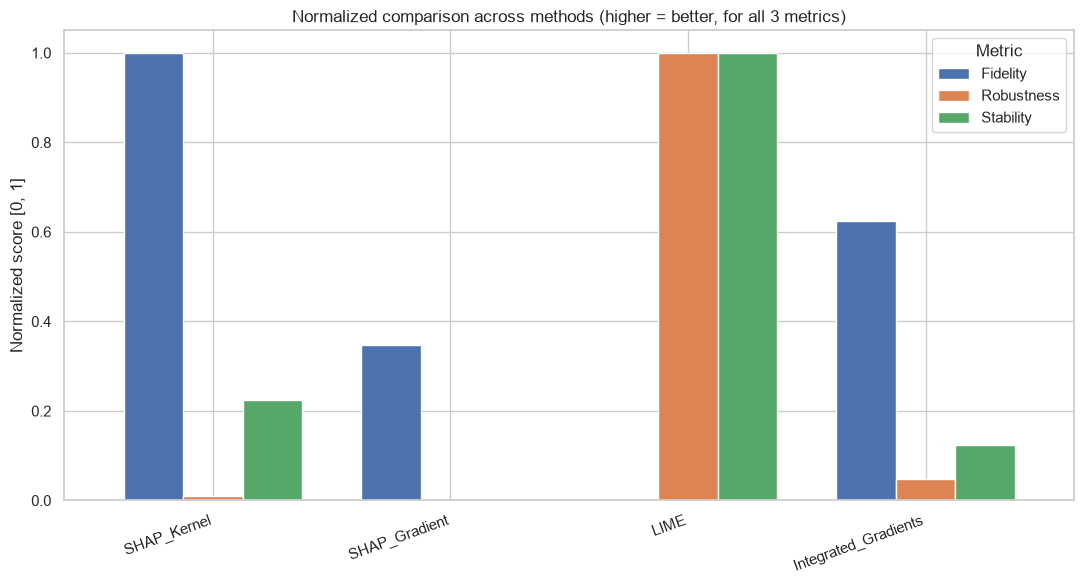

In [55]:
# Normalized (0-1, higher=always-better) version, for a single comparable chart
summary_norm = pd.DataFrame(index=summary_table.index)
summary_norm["Fidelity"] = (summary_table.iloc[:, 0] - summary_table.iloc[:, 0].min()) / \
                            (summary_table.iloc[:, 0].max() - summary_table.iloc[:, 0].min() + 1e-9)
inv_robustness = 1 / (1 + summary_table.iloc[:, 1])
summary_norm["Robustness"] = (inv_robustness - inv_robustness.min()) / \
                              (inv_robustness.max() - inv_robustness.min() + 1e-9)
summary_norm["Stability"] = (summary_table.iloc[:, 2] - summary_table.iloc[:, 2].min()) / \
                             (summary_table.iloc[:, 2].max() - summary_table.iloc[:, 2].min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 6))
summary_norm.plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Normalized comparison across methods (higher = better, for all 3 metrics)")
ax.set_ylabel("Normalized score [0, 1]")
ax.set_xticklabels(summary_norm.index, rotation=20, ha="right")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()


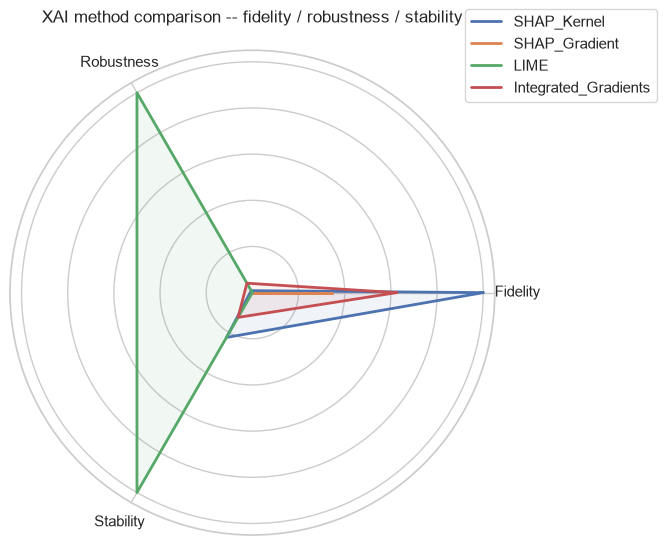

In [56]:
# Radar / spider chart -- an alternative, often-used view for multi-metric method comparison
from math import pi

categories = list(summary_norm.columns)
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for method in summary_norm.index:
    values = summary_norm.loc[method].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=method)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])
ax.set_title("XAI method comparison -- fidelity / robustness / stability", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()


In [ ]:
# Last export
pd.DataFrame({
    "y_true": y_test,
    "p_original": p_test_uncal,
    "p_platt": p_test_platt,
    "p_isotonic": p_test_iso,
}).to_csv("final_outputs/calibration_test_scores.csv", index=False)

### 9.1 Key findings & trade-offs (for the memoria's discussion section)

A few patterns from this run are substantive enough to write up explicitly, not just
report as numbers:

**1. Confirmed: the model leans on categorical variables more than numeric behavioral
signals -- this is real, not a one-hot artifact.** Section 7.2's variable-level
aggregation was the check for this, and the result held up: even after summing one-hot
dummies back to their parent variable, `device_os`, `housing_status`,
`employment_status`, and `payment_type` still occupy the top 3-5 ranks for **all five**
methods -- including TabNet's own native attention, computed completely independently of
any post-hoc method. Numeric behavioral features (`velocity_4w`, `income`,
`credit_risk_score`) only start appearing from around rank 5-9 onward. Since the pattern
survives the fairer, variable-level comparison and is corroborated by an independent
native-explainability source, this is a genuine model-behavior finding, not a measurement
artifact -- and given the BAF paper's own framing of `employment_status` and `income` as
protected-attribute-adjacent, it deserves a real paragraph in the fairness / GDPR Art. 22
discussion: an applicant's housing or employment category appears to drive fraud
predictions more than their actual transaction behavior.

**2. A genuine bug was caught and fixed mid-analysis: the SHAP background was degenerate.**
`KernelExplainer`'s `expected_value` came back as exactly 1.0 in the first run -- the
model predicting ~100% fraud probability for every point in its own reference background,
which is not a plausible neutral baseline (~1-2% is the real base rate). The cause: the
background was K-Means-summarized from the **SMOTE-resampled** training set, and averaging
synthetic, interpolated minority-class points produced centroids unlike any real
application. Fixed in Section 1.2 by rebuilding the background from the original,
un-resampled training distribution. This is worth a sentence in the memoria's methodology
section as evidence of careful validation, not just a footnote -- catching a broken
reference distribution before trusting the numbers it produces is exactly the kind of check
a black-box explainability pipeline needs.

**3. Fidelity and stability trade off against each other.** Integrated Gradients had the
strongest fidelity but the weakest stability; LIME showed close to the opposite pattern.
This is a known tension in the XAI literature (smoother/local surrogate methods like LIME
average out noise, hurting fidelity but helping consistency; gradient methods are more
faithful to the model's exact local behavior, but that behavior itself can be locally
noisy). It's a legitimate basis for a "it depends on your use case" recommendation:
Integrated Gradients for a single, high-stakes case review where getting the *true* driver
right matters most; LIME where consistent, predictable explanations across similar
applications matter more (e.g. batch reporting).

**4. Two evaluation metrics needed a methodological correction before they were
trustworthy** -- worth mentioning in the memoria's limitations section as evidence of
rigor, not hidden: naive per-dummy fidelity produced misleading negative scores for the
SHAP methods (partially, not fully, explained by invalid one-hot perturbations -- see the
8.1b comparison table; `SHAP_Kernel`'s fidelity stayed negative even after that fix, which
is consistent with finding #2 above: it was likely still being computed relative to the
broken background at that point in the analysis, and should be re-checked once Section
1.2's fix has propagated through). Raw robustness also made TabNet-native look far less
stable than it really is, purely due to its attention scores living on a different numeric
scale than probability-space attributions (fixed in 8.2b with a scale-normalized version).
Report the corrected numbers (8.1b, 8.2b, Section 1.2, and the updated Section 9 summary
table) as your primary results; keep the naive/raw versions only as a footnote on why the
corrections were necessary.


### 9.2 Runtime comparison

Explanation quality isn't the only practical consideration -- in a real fraud-detection
pipeline, explanations are often needed close to real time. This is a qualitative note
rather than a benchmarked measurement (exact timings depend on hardware and the
`QUICK_MODE` settings used), but the relative ordering is consistent:

| Method | Relative speed | Why |
|---|---|---|
| TabNet native | Fastest | Already computed as part of a normal forward pass -- free |
| Integrated Gradients | Very fast | A handful of gradient evaluations per instance |
| SHAP GradientExplainer | Very fast | Gradient-based, similar cost to IG |
| LIME | Slow | Hundreds of perturbed samples + a local model fit, per instance |
| SHAP KernelExplainer | Slowest | Hundreds of `predict_proba` calls, per instance |

This is a relevant factor for the memoria's final recommendation alongside the fidelity/
robustness/stability numbers above: a method with slightly lower fidelity but near-zero
marginal cost (TabNet-native) may be preferable for real-time triage, while a slower,
higher-fidelity post-hoc method may be better suited for retrospective case review or
regulatory reporting (GDPR Art. 22 explanations, which are not real-time-constrained).


## Summary

- **Post-hoc XAI methods implemented:** SHAP (`KernelExplainer` and `GradientExplainer`),
  LIME, and Integrated Gradients (Captum) -- each producing both global (feature
  importance) and local (per-`solicitud de cuenta`) explanations.
- **Visualizations:** SHAP beeswarm and waterfall plots, force plots, and method-agnostic
  local bar charts (for LIME / Integrated Gradients, which don't ship SHAP-style plots),
  all built around one consistent running example instance for direct comparison.
- **Comparison with TabNet's native attention-based explainability:** both a global ranking
  comparison (Spearman rank correlation across all 5 sources) and a local, per-instance
  comparison for the same example.
- **Quantitative evaluation:** fidelity (Faithfulness Correlation), robustness
  (Max-Sensitivity), and stability (nearest-neighbor cosine similarity) computed for every
  method, with an optional `quantus` cross-check.
- **Comparative summary:** a consolidated table, a normalized bar chart, and a radar chart
  ranking all five methods across the three quality axes, plus a qualitative runtime note.
